# **ORGANIZATION & NOTEBOOK INITIALIZATION (RUN EVERYTIME)** 

In [1]:
######################################################################
### IMPORT PACKAGES & SETUP NOTEBOOK (RUN AT BEGINNING EVERY TIME) ###
######################################################################

project_name     = 'Wetlab_Data_Analysis'

### REPOSITORY ROOT (auto-detected -- nothing here needs editing) ###
# Walks up from the current directory looking for the repository markers, so
# this notebook works from a fresh clone anywhere on disk. Override by setting
# the ZINC_HYDRO_REPO environment variable if you have an unusual layout.
def _find_repo_root():
    import os as _os
    from pathlib import Path as _Path
    _markers = ('Scripts', 'Software', 'Environment', 'LICENSE')
    _start = _Path(_os.environ.get('ZINC_HYDRO_REPO') or _Path.cwd()).resolve()
    for _cand in (_start, *_start.parents):
        if all((_cand / _m).exists() for _m in _markers):
            return str(_cand)
    raise RuntimeError(
        f"Could not find the repository root above {_start}. "
        f"Start Jupyter from inside the cloned repository, or set ZINC_HYDRO_REPO."
    )

github_repo_dir = _find_repo_root()
# NOTE: this notebook needs no external tools -- only numpy/pandas/scipy/
#       matplotlib/openpyxl. Open Babel belongs to the DESIGN pipelines.

# 1.) subfolders to build in notebook directory
wrk_dirs_list = [
    'raw_wetlab_data', 'wetlab_data_plots' # optionally add more input subdirectories
]

###################################################### AUTO SETUP ######################################################
### STANDARD LIBRARY IMPORTS ###
import shlex, glob, json, math, os, random, copy, re, shutil, statistics, string, subprocess, sys
import textwrap, warnings, concurrent.futures, time, multiprocessing, itertools, operator
from pathlib import Path
from datetime import datetime

### DERIVED PATHS (CHANGE AT USER DISCRETION) ###
scripts_dir   = f'{github_repo_dir}/Scripts/'
software_dir  = f'{github_repo_dir}/Software/'
working_dir   = f'{github_repo_dir}/Manuscript_Data/Metallohydrolase_Nature_2026/'

for p in [working_dir, scripts_dir, software_dir]: 
    Path(p).mkdir(parents=True, exist_ok=True) # ensure base dirs exist so downstream cells never fail on missing paths

### 3RD PARTY IMPORTS ###
import numpy as np
import pandas as pd

### CUSTOM IMPORTS ###
if scripts_dir not in sys.path:
    sys.path.append(scripts_dir)
import General_NoteBook_Functions as functions
from experimental_data_processing_functions import *

### FIGURE OUTPUT (applies to every figure this notebook writes) ###
# All figures are written to wetlab_data_plots/ as PNG. PNG at a modest DPI
# keeps the repository small -- these are the files committed to GitHub.
# EPS is vector and much larger, so it is off by default; flip SAVE_EPS to True
# (or pass save_eps=True at a single call site) when you need one for a figure.
FIGURE_DPI = 150     # raster resolution for the PNGs
SAVE_EPS   = False   # also write <name>.eps alongside <name>.png

import experimental_data_processing_functions as _edpf
_edpf.FIGURE_DPI, _edpf.SAVE_EPS = FIGURE_DPI, SAVE_EPS   # keep helper defaults in step

### SETUP SUBDIRECTORIES & CREATE VARIABLES ###
functions.setup_directories(working_dir, wrk_dirs_list, export_globals=True, globals_dict=globals())

### OPTIONALS ###
functions.set_pandas_display(all_on=True) # pandas display comfort defaults (toggle here if desired)
os.chdir(working_dir) # move into working dir for relative IO

### PRINTS ###
print(f"### PROJECT {project_name} NOTEBOOK SUCCESSFULLY INITIALIZED ON {datetime.now().strftime('%Y-%m-%d AT TIME %H:%M:%S')} ### ")
print(f"\nExample Variables & Paths:")
print(f"   working_dir        = {working_dir}")
print(f"   raw_wetlab_data    = {raw_wetlab_data_dir}")
print(f"   figures are written to: {wetlab_data_plots_dir}")


### PROJECT Wetlab_Data_Analysis NOTEBOOK SUCCESSFULLY INITIALIZED ON 2026-09-29 AT TIME 20:52:52 ### 

Example Variables & Paths:
   working_dir        = /home/woodbuse/publication/metallohydrolase/official_github/Metallohydrolase_Enzyme_Design/Manuscript_Data/Metallohydrolase_Nature_2026/
   raw_wetlab_data    = /home/woodbuse/publication/metallohydrolase/official_github/Metallohydrolase_Enzyme_Design/Manuscript_Data/Metallohydrolase_Nature_2026/raw_wetlab_data/
   figures are written to: /home/woodbuse/publication/metallohydrolase/official_github/Metallohydrolase_Enzyme_Design/Manuscript_Data/Metallohydrolase_Nature_2026/wetlab_data_plots/


# **I. FUNCTIONAL SCREENING DATA** 

## I.I. Design Campaign 1 Screening Results

### I.I.A. 96-Well Grid Plot of Individual Reaction Progress Curves

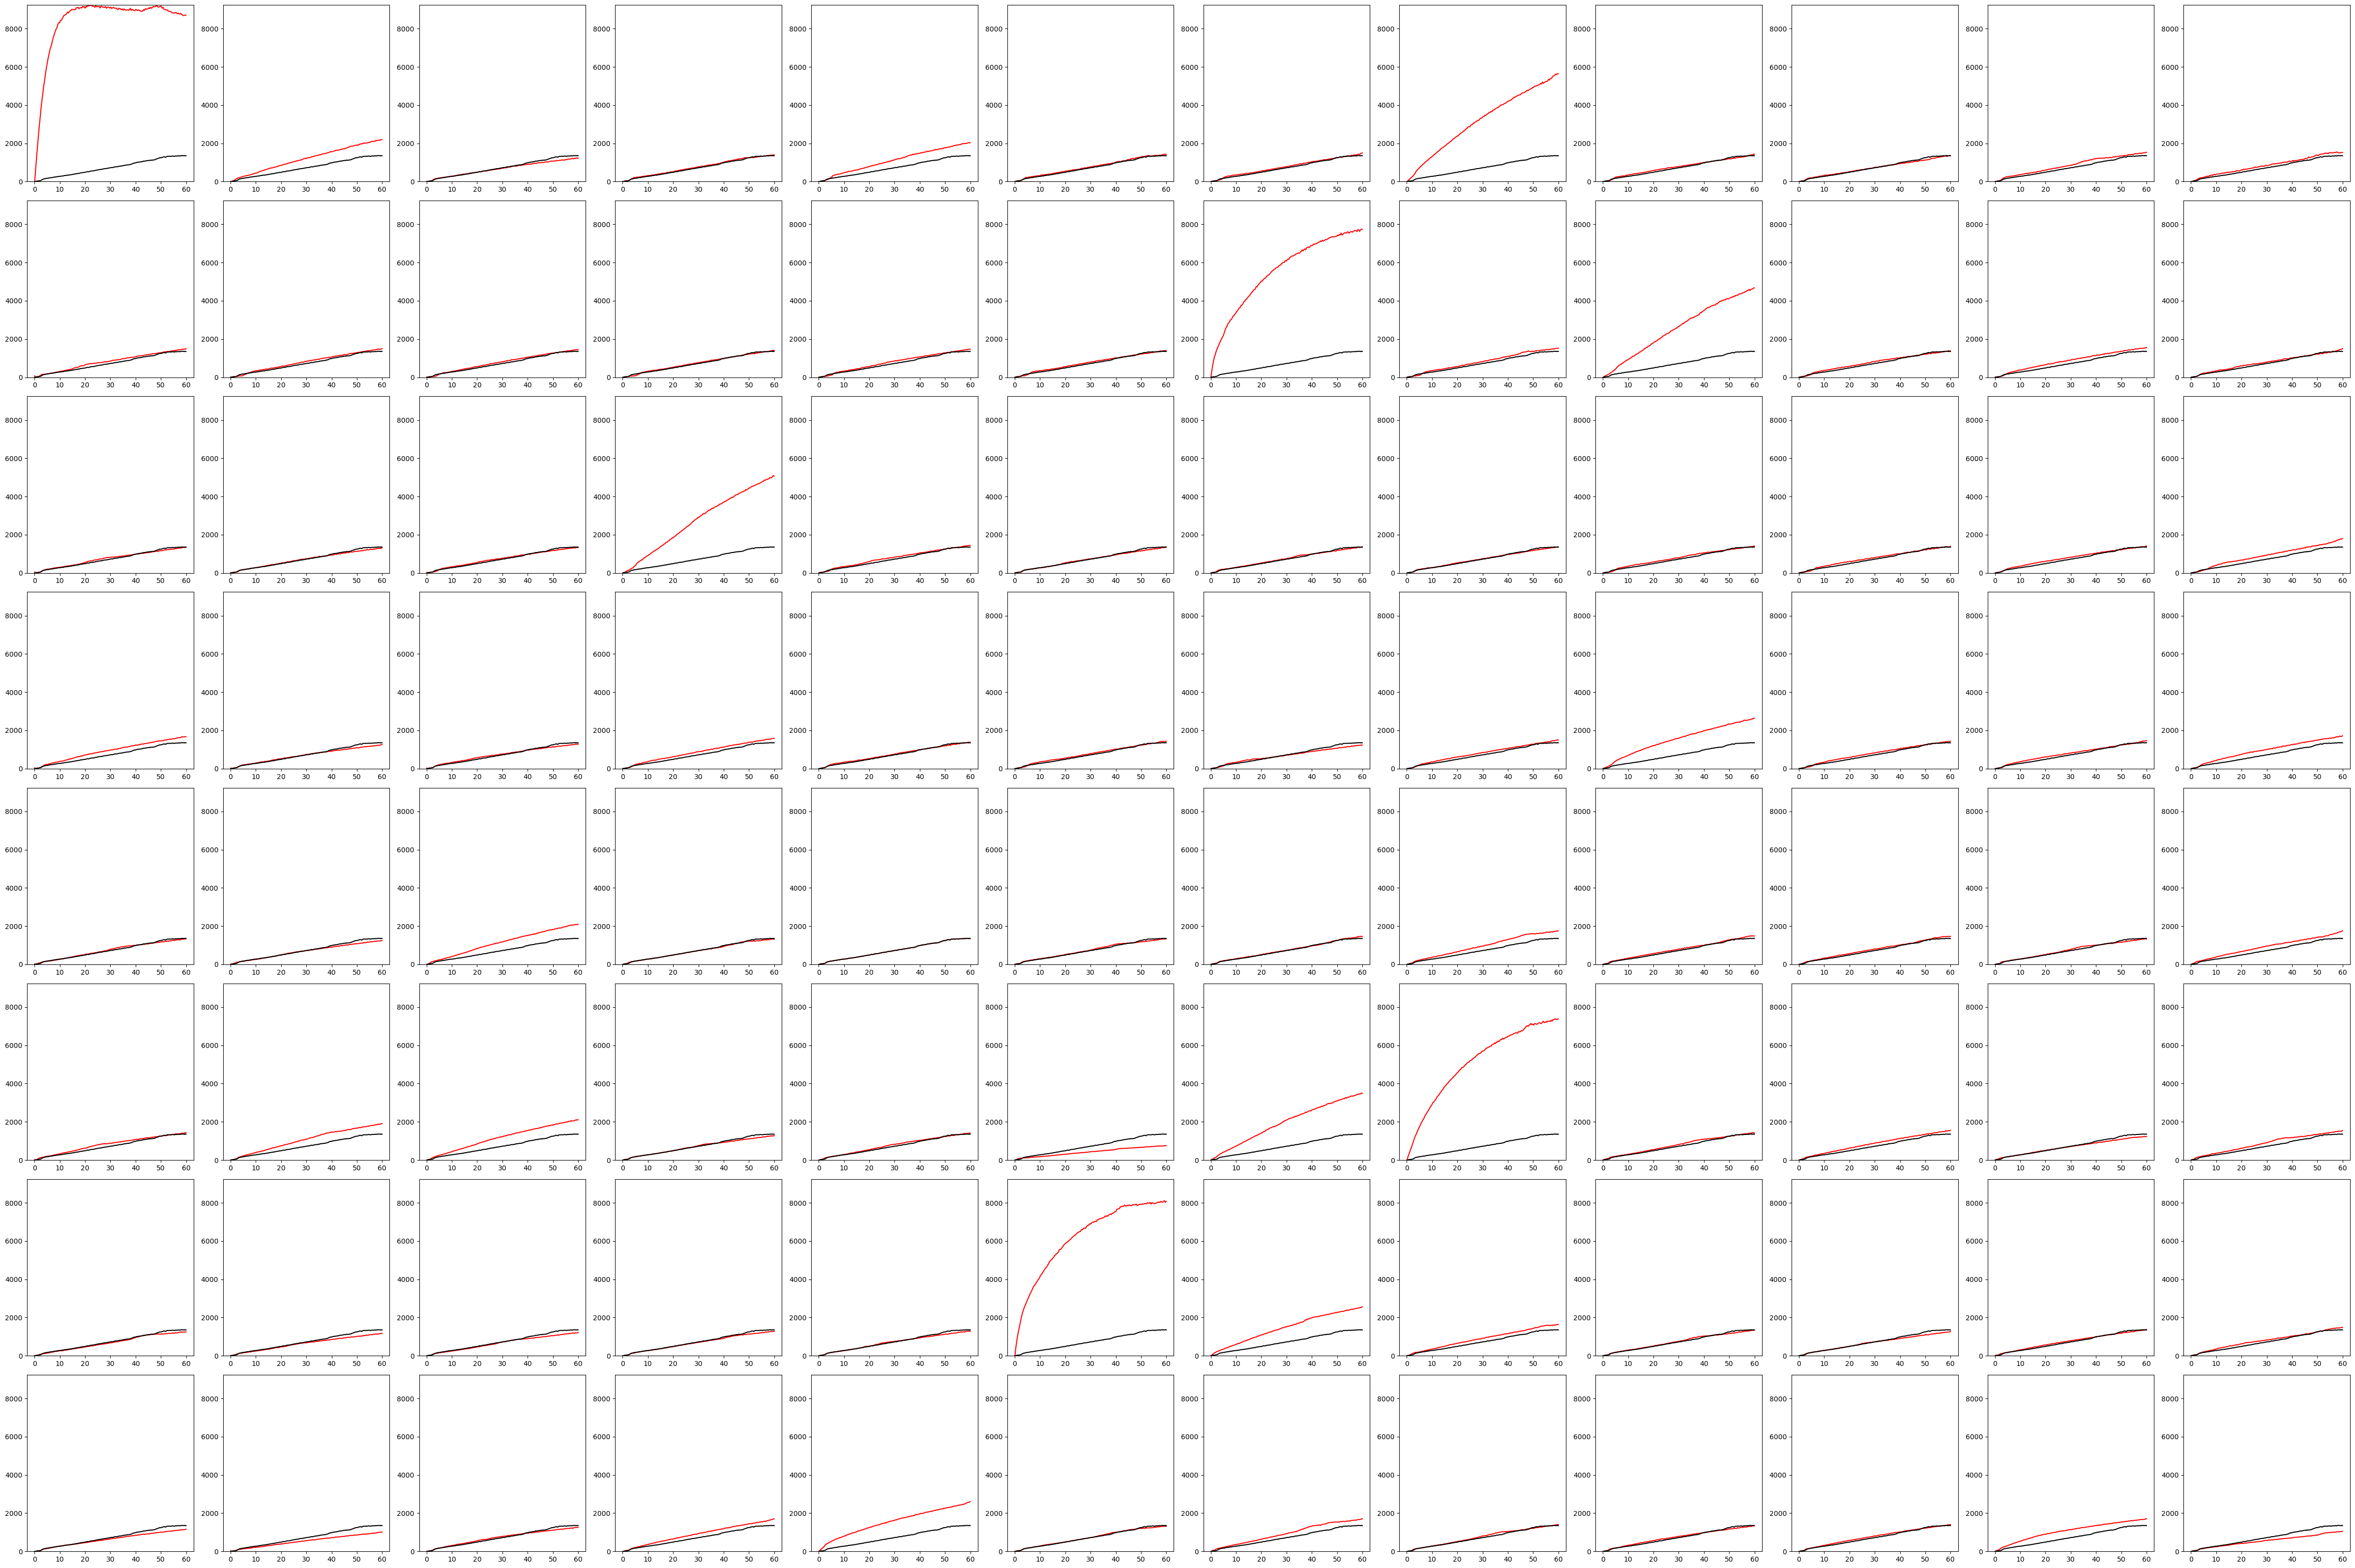

In [2]:
# Load the CSV file
file_path1 = f'{raw_wetlab_data_dir}240709_4mu_PA_ABCD.tsv'
data1 = pd.read_csv(file_path1, sep="\t")
data1_rename_dic = {"Time": "Time", "T° 365,445": "T° 365,445"}
for i, new_row in enumerate("AABBCCDD"):
    ori_row = "ABCDEFGH"[i]
    for col in range(1, 13):
        if i%2 == 0:
            data1_rename_dic[f"{ori_row}{col}"]= f"{new_row}{col}_wZN"
        else:
            data1_rename_dic[f"{ori_row}{col}"]= f"{new_row}{col}_woZN"
data1.rename(columns=data1_rename_dic, inplace=True)

# Load the CSV file
file_path2 = f'{raw_wetlab_data_dir}240711_4mu_PA_EFGH.tsv'
data2 = pd.read_csv(file_path2, sep="\t")
data2_rename_dic = {"Time": "Time", "T° 365,445": "T° 365,445"}
for i, new_row in enumerate("EEFFGGHH"):
    ori_row = "ABCDEFGH"[i]
    for col in range(1, 13):
        if i%2 == 0:
            data2_rename_dic[f"{ori_row}{col}"]= f"{new_row}{col}_wZN"
        else:
            data2_rename_dic[f"{ori_row}{col}"]= f"{new_row}{col}_woZN"
### PLATE RELABELING ###
# Wells E6 and F6 hold the G6 sample pair (without and with Zn(II));
# remap them to their correct identities before analysis.
data2_rename_dic["E6"] = "G6_woZN"
data2_rename_dic["F6"] = "G6_wZN"
### END PLATE RELABELING ###

data1.rename(columns=data1_rename_dic, inplace=True)
data2.rename(columns=data2_rename_dic, inplace=True)

data = pd.merge(data1, data2, on='Time', how='inner')

# Convert 'Time' to a more usable format (assuming it's in hh:mm:ss)
data['Time'] = pd.to_timedelta(data['Time'])
data['Time'] = data['Time'].dt.total_seconds() / 60  # Convert time to minutes

# Standardization and Normalization
for letter in 'ABCDEFGH':
    for num in range(1, 13):
        #data[f'{letter}{num}_wZN'] = data[f'{letter}{num}_wZN'] - data[f'{blank_well}_wZN']
        data[f'{letter}{num}_wZN'] = data[f'{letter}{num}_wZN'] - np.min(data[f'{letter}{num}_wZN'].to_list())
        #data[f'{letter}{num}_woZN'] = data[f'{letter}{num}_woZN'] - data[f'{blank_well}_woZN']
        data[f'{letter}{num}_woZN'] = data[f'{letter}{num}_woZN'] - np.min(data[f'{letter}{num}_woZN'].to_list())


# Define pairs for plotting
pairs = []
for letter in 'ABCDEFGH':
    for num in range(1, 13):
        pairs.append((f'{letter}{num}_wZN', f'E5_wZN'))

# Find global min and max values for normalization
y_min = data[[col for pair in pairs for col in pair]].min().min()
y_max = data[[col for pair in pairs for col in pair]].max().max()

# Set up the plot grid
num_plots = len(pairs)
cols = 12
rows = (num_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = axes.flatten()

# Custom titles and spine colors
custom_titles = {
    'B6': "PC1",
    'B7': "PC2",
    'D7': 'Blank (rxn buffer only)',
    'E5': 'Blank (rxn buffer only)',
    'F8': "C4",
    'G4': "PC1",
    'G6': "PC2",
    'H2': 'Blank (rxn buffer only)',
}
# Plot each pair
for i, (col1, col2) in enumerate(pairs):
    ax = axes[i]
    
    # Plot the data
    ax.plot(data['Time'], data[col1], color='red')
    ax.plot(data['Time'], data[col2], color='black')
    
    # Set axis labels and title
    #ax.set_xlabel('Time (minutes)')
    #ax.set_ylabel('Fluorescence Units')
    
    ax.set_ylim(y_min, y_max)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

cute_pics_dir = wetlab_data_plots_dir
    
plt.tight_layout()
save_figure(f'{cute_pics_dir}240709_4mu_PA_screening', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()


### I.I.B. Combined Plot of Reaction Progress Curves

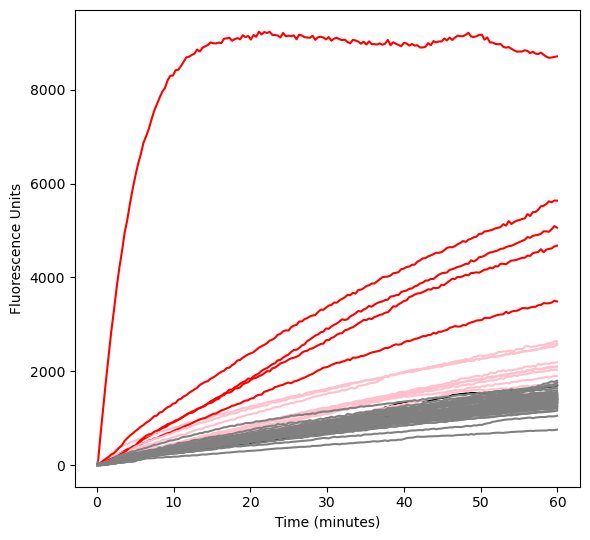

In [3]:
# Load the CSV file
file_path1 = f'{raw_wetlab_data_dir}240709_4mu_PA_ABCD.tsv'
data1 = pd.read_csv(file_path1, sep="\t")
data1_rename_dic = {"Time": "Time", "T° 365,445": "T° 365,445"}
for i, new_row in enumerate("AABBCCDD"):
    ori_row = "ABCDEFGH"[i]
    for col in range(1, 13):
        if i%2 == 0:
            data1_rename_dic[f"{ori_row}{col}"]= f"{new_row}{col}_wZN"
        else:
            data1_rename_dic[f"{ori_row}{col}"]= f"{new_row}{col}_woZN"
data1.rename(columns=data1_rename_dic, inplace=True)

# Load the CSV file
file_path2 = f'{raw_wetlab_data_dir}240711_4mu_PA_EFGH.tsv'
data2 = pd.read_csv(file_path2, sep="\t")
data2_rename_dic = {"Time": "Time", "T° 365,445": "T° 365,445"}
for i, new_row in enumerate("EEFFGGHH"):
    ori_row = "ABCDEFGH"[i]
    for col in range(1, 13):
        if i%2 == 0:
            data2_rename_dic[f"{ori_row}{col}"]= f"{new_row}{col}_wZN"
        else:
            data2_rename_dic[f"{ori_row}{col}"]= f"{new_row}{col}_woZN"
### PLATE RELABELING ###
# Wells E6 and F6 hold the G6 sample pair (without and with Zn(II));
# remap them to their correct identities before analysis.
data2_rename_dic["E6"] = "G6_woZN"
data2_rename_dic["F6"] = "G6_wZN"
### END PLATE RELABELING ###

data1.rename(columns=data1_rename_dic, inplace=True)
data2.rename(columns=data2_rename_dic, inplace=True)

data = pd.merge(data1, data2, on='Time', how='inner')

# Convert 'Time' to a more usable format (assuming it's in hh:mm:ss)
data['Time'] = pd.to_timedelta(data['Time'])
data['Time'] = data['Time'].dt.total_seconds() / 60  # Convert time to minutes

# Standardization and Normalization
for letter in 'ABCDEFGH':
    for num in range(1, 13):
        data[f'{letter}{num}_wZN'] = data[f'{letter}{num}_wZN'] - np.min(data[f'{letter}{num}_wZN'].to_list())
        data[f'{letter}{num}_woZN'] = data[f'{letter}{num}_woZN'] - np.min(data[f'{letter}{num}_woZN'].to_list())


# Define pairs for plotting
pairs = []
for letter in 'ABCDEFGH':
    for num in range(1, 13):
        pairs.append((f'{letter}{num}_wZN', f'E5_wZN'))

# Find global min and max values for normalization
y_min = data[[col for pair in pairs for col in pair]].min().min()
y_max = data[[col for pair in pairs for col in pair]].max().max()

# Set up the plot grid
plt.figure(figsize=(6, 5.5))

# Custom titles and spine colors
custom_titles = {
    'B6': "PC1",
    'B7': "PC2",
    'D7': 'Blank (rxn buffer only)',
    'E5': 'Blank (rxn buffer only)', # We chose this one
    'F8': "C4",
    'G4': "PC1",
    'G6': "PC2",
    'H2': 'Blank (rxn buffer only)',
}

# Plot all the wells excluding positive controls and one blank
for col in range(1,13):
    for row in "ABCDEFGH":
        well = f"{row}{col}"
        # Exclude the positive controls and the unused blank
        if well in ["B6", "B7", "D7", "F8", "G4", "G6", "H2"]: continue

        # Big Hits
        if well in ["A1", "A8", "B9", "C4", "F7"]: 
            plt.plot(data['Time'], data[well+"_wZN"], label=well, color='red')
        # Intermediate Hits
        elif well in ["A2", "A5", "D9", "E3", "E8", "F2", "F3", "G7", "H5"]:
            plt.plot(data['Time'], data[well+"_wZN"], label=well, color='pink')
        # Non-Hit example
        elif well in ["H7", "H8"]:
            plt.plot(data['Time'], data[well+"_wZN"], label=well, color='black')
        # Blank
        elif not well in ["A1", "A8", "B9", "C4", "F7", "E5"]:
            plt.plot(data['Time'], data[well+"_wZN"], label=well, color='gray')
        # Small or Non hits
        elif well == "E5":
            plt.plot(data['Time'], data[well+"_wZN"], label=well, color='black', linestyle='dashed')
    
    # Set axis labels and title
    plt.xlabel('Time (minutes)')
    plt.ylabel('Fluorescence Units')
    
plt.tight_layout()
save_figure(f'{wetlab_data_plots_dir}241006_4muPA_integrated_screening_results', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()


## I.II. Design Campaign 2 Screening Results

In [4]:
# Plate reader screening functions (parse_excels, trim_time_end, trim_time_start,
# normalize_to_first_row, normalize_to_min, draw_progression_curve_v0,
# draw_progression_curve_seperate_v0) are imported via the setup cell

### I.II.A. 96-Well Grid Plot of Individual Reaction Progress Curves

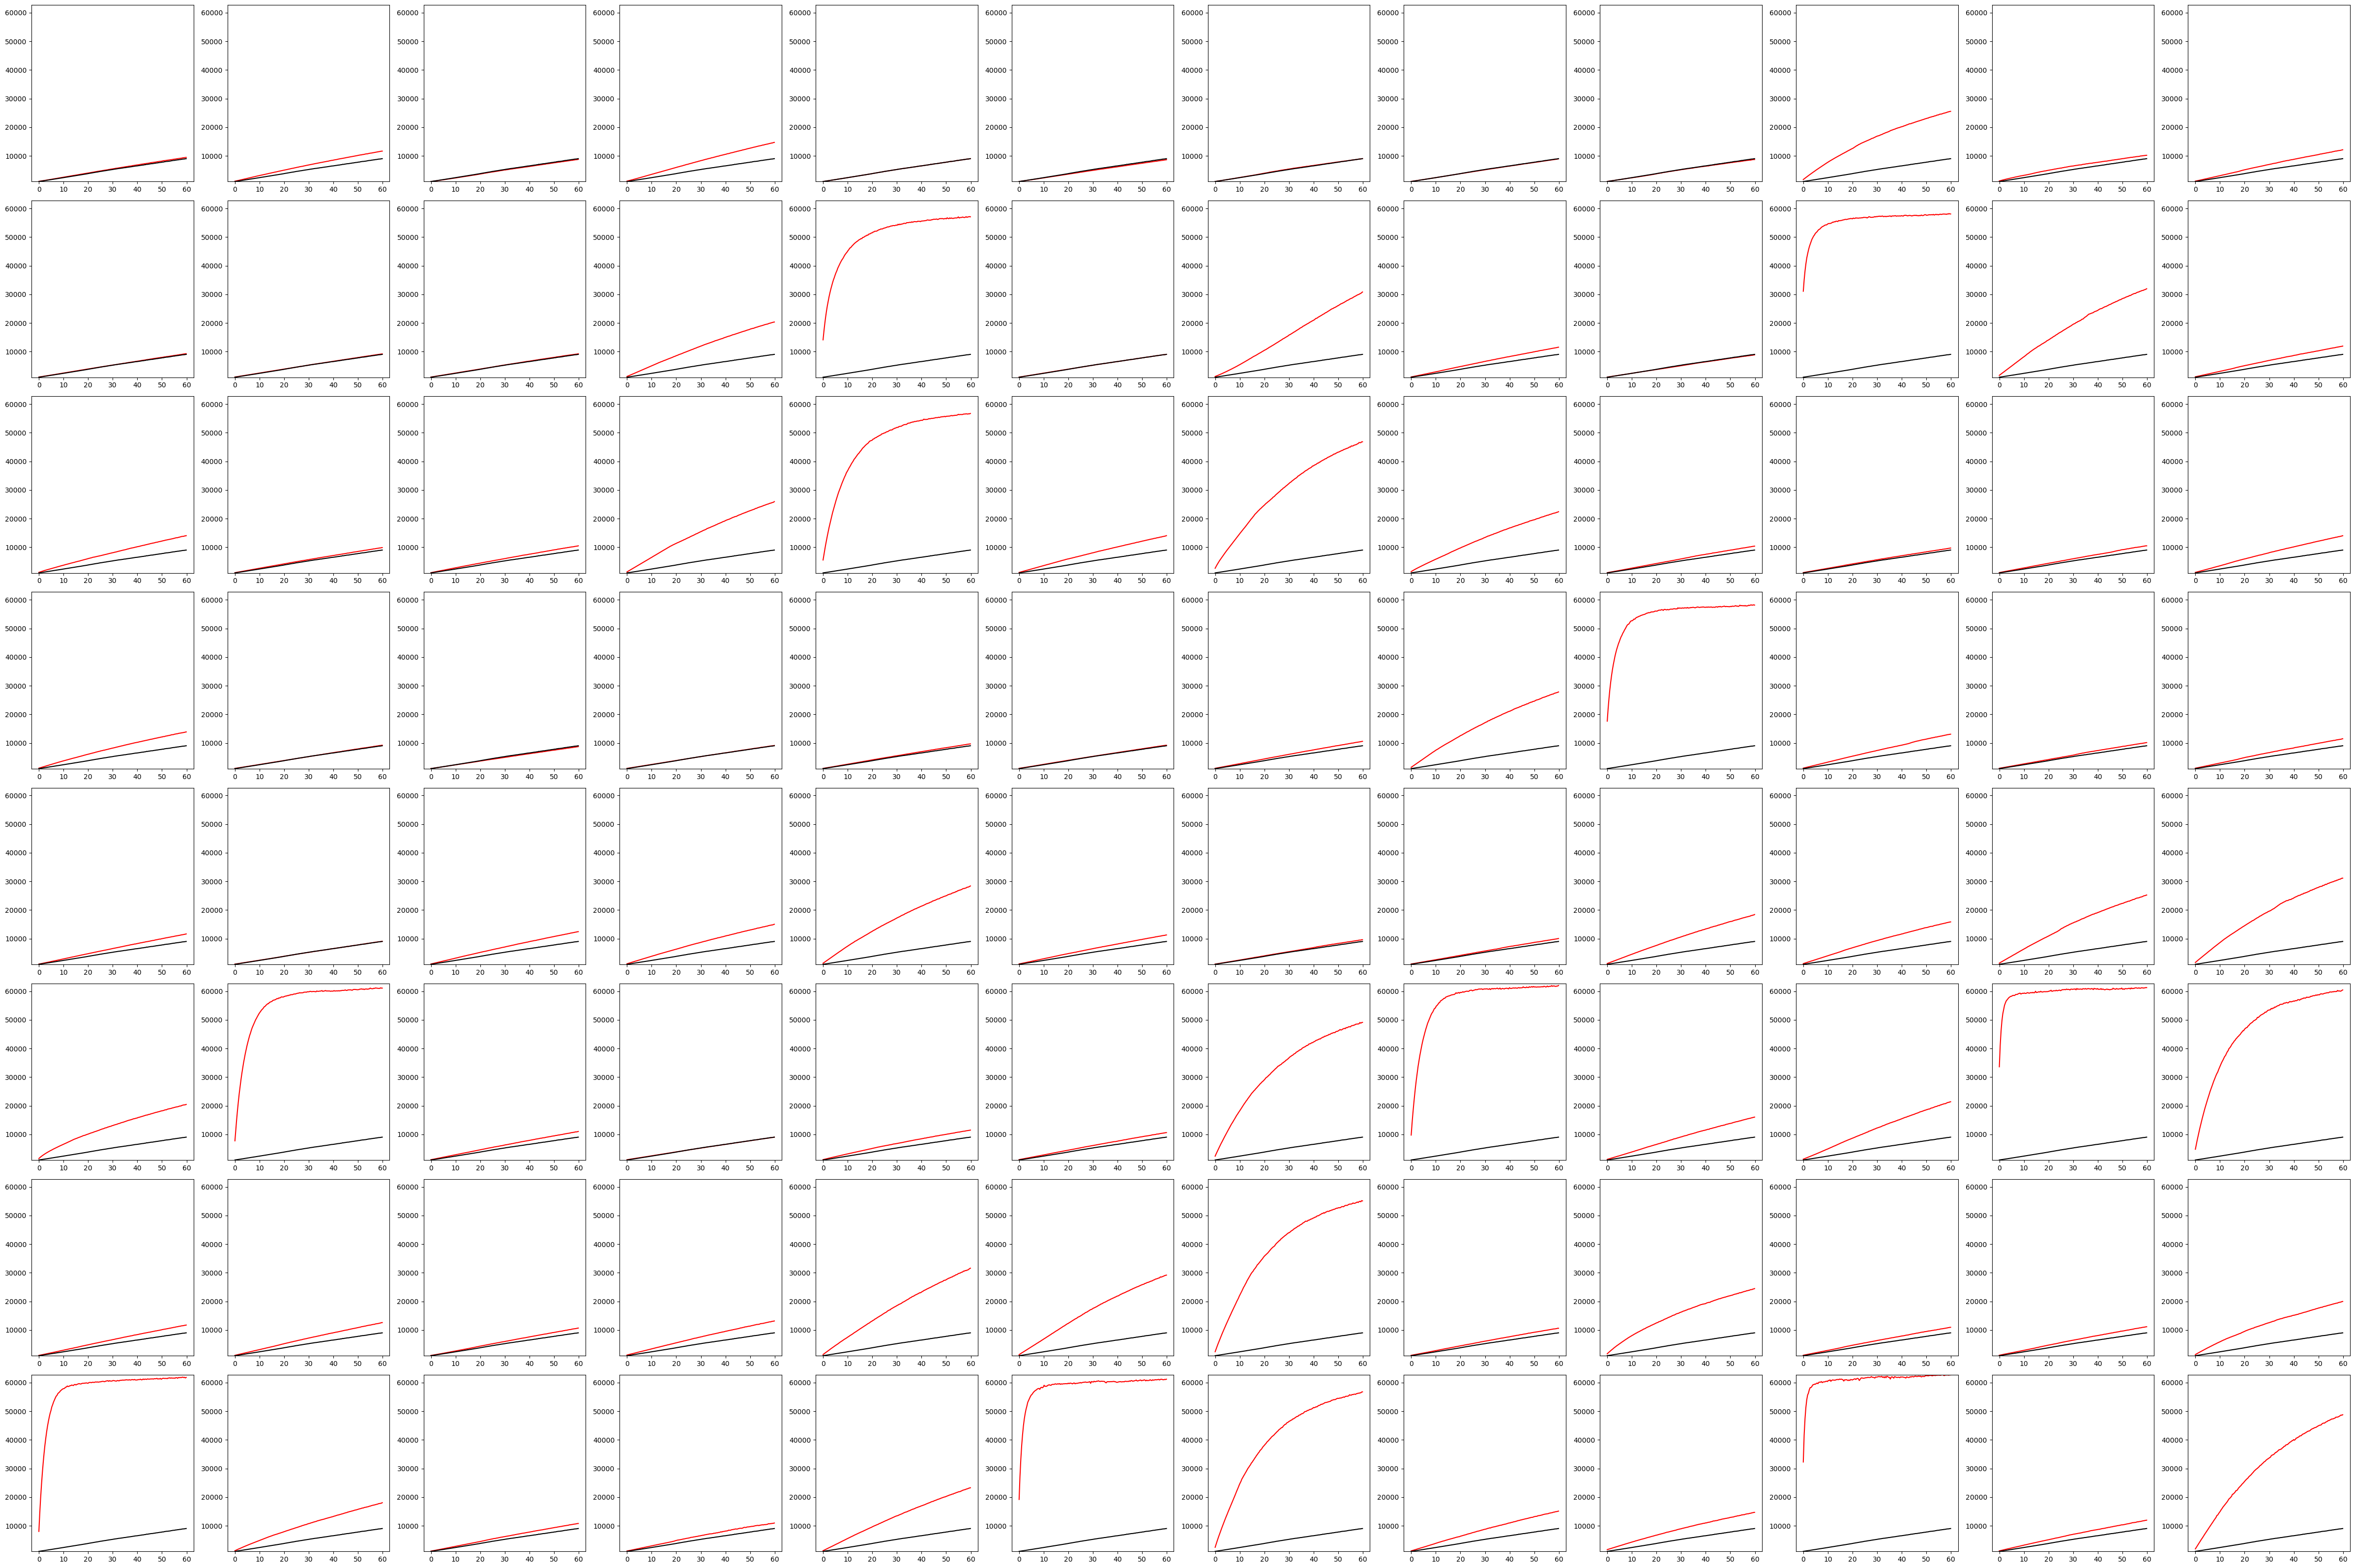

In [5]:
### Input
excel_file = f'{raw_wetlab_data_dir}250307_singleZn_order1_cowboy_elutantScreen_100uM_4MUPA_and_100uM_suppZn_25C.xlsx'
eps_out = f'{wetlab_data_plots_dir}250307_screening_result_100uM_4MUPA_100uM_suppZn_25C_separated'
rows, columns = list("ABCDEFGH"), list(range(1,13))
bg = "A5"
time_start = 0
time_end = 60
# Scaffold1: ["F2", "F8", "F11", "H1", "H10"]
# Scaffold2: ["B5", "B10", "D9", "F12", "H6"]
# Scaffold3: ["C5"]

draw_progression_curve_seperate_v0(excel_file, rows, columns, bg, time_start, time_end, start_row=48, reverse=False, save=eps_out, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### I.II.B. Combined Plot of Reaction Progress Curves

Hits are: H10, F8, H1, F11, H6, F2, F12, D9, B10, B5, H7, C5, G7


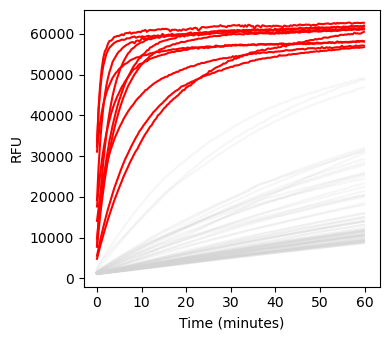

In [6]:
### Input
#excel_file = os.path.join(net_exp_woodbuse, "neo2_platereader/zinc_hydrolase_ULTRAop/single_zinc_esterase/", "250307_singleZn_order1_cowboy_elutantScreen_100uM_4MUPA_and_100uM_suppZn_25C.xlsb")
excel_file = f'{raw_wetlab_data_dir}250307_singleZn_order1_cowboy_elutantScreen_100uM_4MUPA_and_100uM_suppZn_25C.xlsx'
eps_out = f'{wetlab_data_plots_dir}250307_screening_result_100uM_4MUPA_100uM_suppZn_25C'
rows, columns = list("ABCDEFGH"), list(range(1,13))
hit_definition_num = 13
blank = []
time_start = 0
time_end = 60
ignore = ["A5", "A8", "B6", "E8", "F4", "G2", "G7", "G10", "G11", "H7", "H9"]
# Scaffold1: ["F2", "F8", "F11", "H1", "H10"]
# Scaffold2: ["B5", "B10", "D9", "F12", "H6"]
# Scaffold3: ["C5"]

draw_progression_curve_v0(excel_file, rows, columns, hit_definition_num, blank, time_start, time_end, label=False, start_row=48, ignore=ignore, reverse=False, save=eps_out, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

## I.III. ZETA_1 (A1) Variant Screening Results

### I.III.A. Combined Plot of Reaction Progress Curves

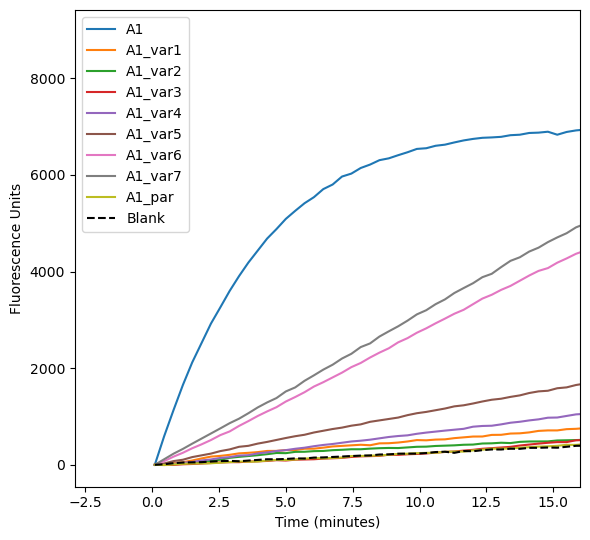

In [7]:
# Load the CSV file
file_path1 = f'{raw_wetlab_data_dir}240826_zn_hydrolase_donghyo_knockouts_AND_variants_200uM_zn_25uM_PA_AND_100uM_PA.xlsx'
data1 = pd.read_excel(file_path1, header=48, skipfooter=36)
data = data1.copy()
data = data.dropna(axis=1, how='all').dropna(axis=0, how='all')
data.reset_index(drop=True, inplace=True)

# Convert 'Time' to a more usable format (assuming it's in hh:mm:ss)
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M:%S', errors='coerce')

# Calculate total seconds and convert to minutes
data['Time'] = (data['Time'] - pd.Timestamp('1900-01-01 00:00:00')).dt.total_seconds() / 60

# Set up the plot grid
plt.figure(figsize=(6, 5.5))

active_wells = ["A1", "E11", "E12", "F1", "F2", "F3", "F4", "F5", "F6", "F7"]


# Zero-ing
for well in active_wells:
    data[well] = data[well] - data[well].to_list()[0]

# Plot all the wells
for i, well in enumerate(active_wells):
    if i == 0:
        plt.plot(data['Time'], data[well], label=well)
    elif i < 8:
        plt.plot(data['Time'], data[well], label=f"A1_var{i}")
    elif i == 8:
        plt.plot(data['Time'], data[well], label=f"A1_par")
    else:
        plt.plot(data['Time'], data[well], label="Blank", linestyle='dashed', color='black')
    
    # Set axis labels and title
    plt.xlabel('Time (minutes)')
    xlim = plt.xlim()
    plt.xlim(xlim[0], 16)
    plt.ylabel('Fluorescence Units')
    
plt.tight_layout()
plt.legend()
save_figure(f'{wetlab_data_plots_dir}240826_A1_variations_progression_curves', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()


## I.IV. ZETA_1 (A1) Mutant (Knockout) Screening Results

### I.IV.A. Combined Plot of Reaction Progress Curves

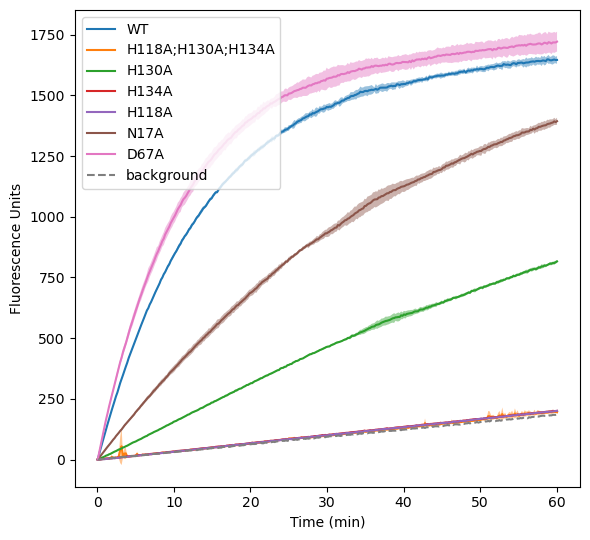

In [8]:
# excel file output from neo2
excel_file = f'{raw_wetlab_data_dir}240906_a1_plus_6mutants_AND_standard_curve___1pt8_uM_4muPA_100nM_enz_25C_1hr.xlsx'

# Specify row and column ranges
row_column_ranges = {
    'A': (1, 7),
    'B': (1, 7),
    'C': (1, 7),
    'D': (1, 7),
    'E': (1, 7),
    'F': (1, 7),
    'G': (1, 7),
}

# Specify replicates
replicate_dic = {
    1: [2, 3]
}

# Specify background
background_col = 4

# Create an empty list to store active wells
active_wells = []

# Iterate through rows/columns, append to active wells
for row, (start_col, end_col) in row_column_ranges.items():
    for col in range(start_col, end_col + 1):
        active_wells.append(f"{row}{col}")

# Specify standarization slope
slope = np.average([6.857301209337525e-10, 7.101340604738747e-10, 7.18193078001004e-10])  # 240906 calibration; same value as SLOPE_4MU_240906, derived in II.I.A (defined later, so kept literal here)

# Load data
screening_data = parse_kinetics(excel_file, active_wells, start_row=48)
"""
# Standardize
for well in active_wells:
    fu = screening_data[well].values
    product_concentration = fu * slope * 1000000
    screening_data[well] = product_concentration
"""
# Zero-ing        
for well in active_wells:
    screening_data[well] = screening_data[well] - np.min(screening_data[well])

"""
# Normalize
for well in active_wells:
    row = well[0]
    screening_data[well] = np.array(screening_data[well]) - np.array(screening_data[f'{row}{background_col}'])
"""
# Convernting time
screening_data["Time"] = screening_data["Time"]/60

plt.figure(figsize=(6, 5.5))

for representive_col in replicate_dic:
    replicates = [representive_col]
    replicates.extend(replicate_dic[representive_col])
    
    for row, name in zip(["A", "B", "C", "D", "E", "F", "G"], ["WT", "H118A;H130A;H134A", "H130A", "H134A", "H118A", "N17A", "D67A"]):
        
        replicates_well = [f"{row}{col}" for col in replicates]
        avg_product_concentration = np.array(screening_data[replicates_well].mean(axis=1).tolist())
        std_product_concentration = np.array(screening_data[replicates_well].std(axis=1).tolist())
        
        plt.plot(screening_data["Time"].values, avg_product_concentration, label=name)
        plt.fill_between(screening_data["Time"].values, 
                             avg_product_concentration - std_product_concentration,
                             avg_product_concentration + std_product_concentration,
                             alpha = 0.45)
        
    plt.plot(screening_data["Time"].values, screening_data[f"{row}{background_col}"], linestyle='dashed', label="background")
    
    #plt.ylabel("[4MU] (uM)")
    plt.ylabel("Fluorescence Units")
    plt.xlabel("Time (min)")

plt.legend()
plt.tight_layout()
save_figure(f'{wetlab_data_plots_dir}A1_KO_experiment_progression_curves', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()

# **II. KINETIC MEASUREMENT DATA** 

## II.I. Standard Curves & Background Reaction Rate (*k*<sub>uncat</sub>)



### II.I.A. 4-Methylumbelliferone (4MU) Standard Curve

Every kinetic measurement in this notebook is recorded as raw fluorescence units
(FU). Converting FU to product concentration requires a calibration slope, in
M per FU, measured from a dilution series of free 4-methylumbelliferone read on
the same instrument under the same gain settings.

The cell below derives the three calibration slopes this notebook uses, each
from its own standard-curve plate in `raw_wetlab_data/`:

| Constant | Plate | Applied to |
|---|---|---|
| `SLOPE_4MU_250401` | `250401_4mu_standard_curves_..._pH8` | the Michaelis-Menten series (Sections II and IV) |
| `SLOPE_4MU_240927` | `240927_4mu_standard_curves_...LadderLEFT3_100uMLadderRIGHT3` | Section II.IV.C, A1 H130A |
| `SLOPE_4MU_240906` | `240906_a1_plus_6mutants_AND_standard_curve_...` | Section I.IV, A1 knockout screen |

Each plate carries two serial dilution ladders, fitted together as a single
twelve-point curve and repeated in triplicate; the three replicate slopes are
averaged. On the 250401 plate the ladders run across columns (30 uM in 1-6,
45 uM in 7-12, rows D/E/F). On the 240927 plate they run down the rows (80 uM in
plate columns 1-3, 100 uM in columns 4-6), so that plate is transposed before
fitting.

Instrument gain differs between sessions, so each calibration is applied only to
the experiments recorded alongside it. Defining them here means a calibration is
changed in one place rather than in every analysis cell.


--- replicate row A ---
Slope: 6.888273668788148e-10, Intercept: 6.180232182166837e-09


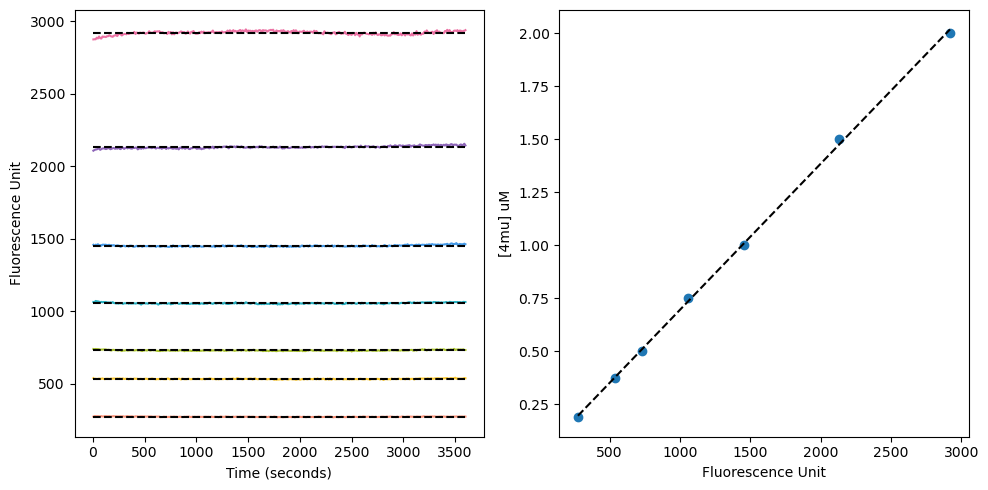

--- replicate row B ---
Slope: 7.059087100301018e-10, Intercept: -9.475405929877545e-09


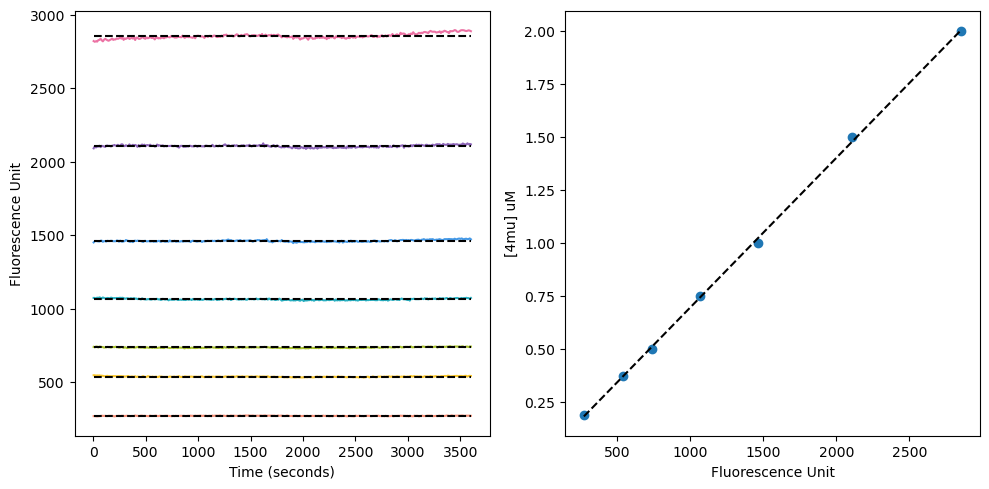

--- replicate row C ---
Slope: 7.131323239898457e-10, Intercept: -1.2127524654502314e-08


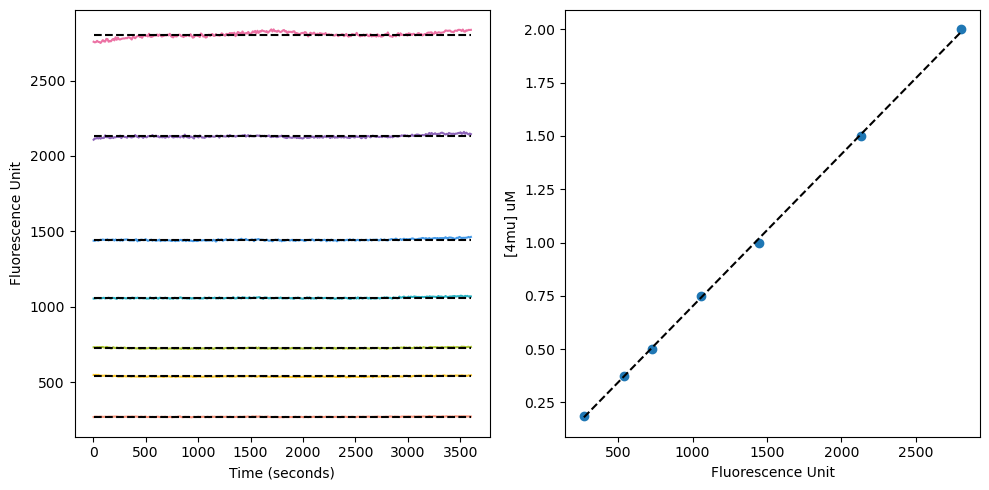


Derived from the shipped plate : 7.026228e-10 M / FU


--- 250401 replicate row D ---
Slope: 9.296712951159367e-10, Intercept: -1.1844204142708292e-06


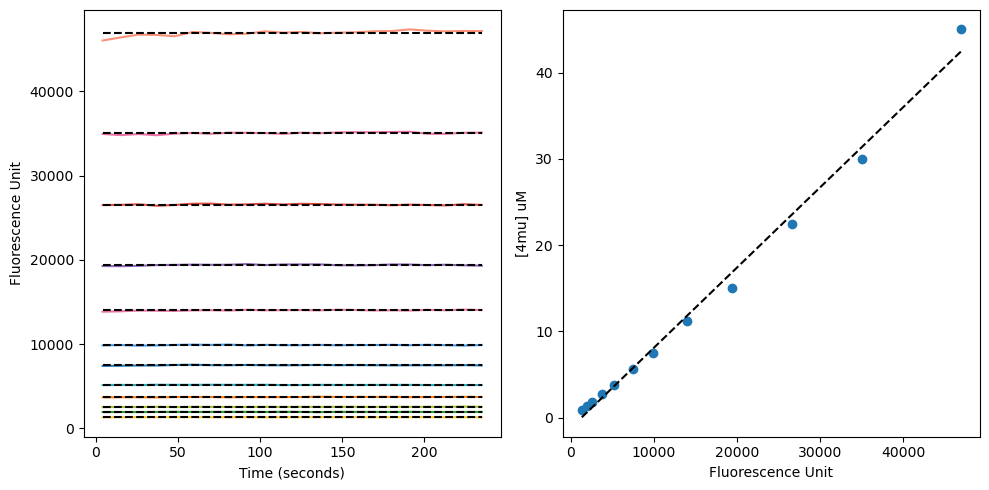

--- 250401 replicate row E ---
Slope: 9.447803716354774e-10, Intercept: -1.2793396323801954e-06


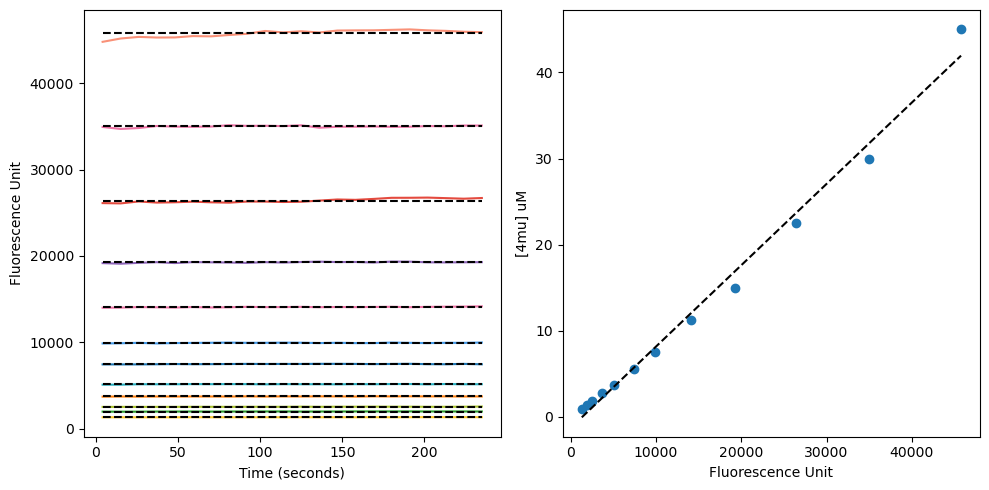

--- 250401 replicate row F ---
Slope: 9.40363467934009e-10, Intercept: -1.1365045883997506e-06


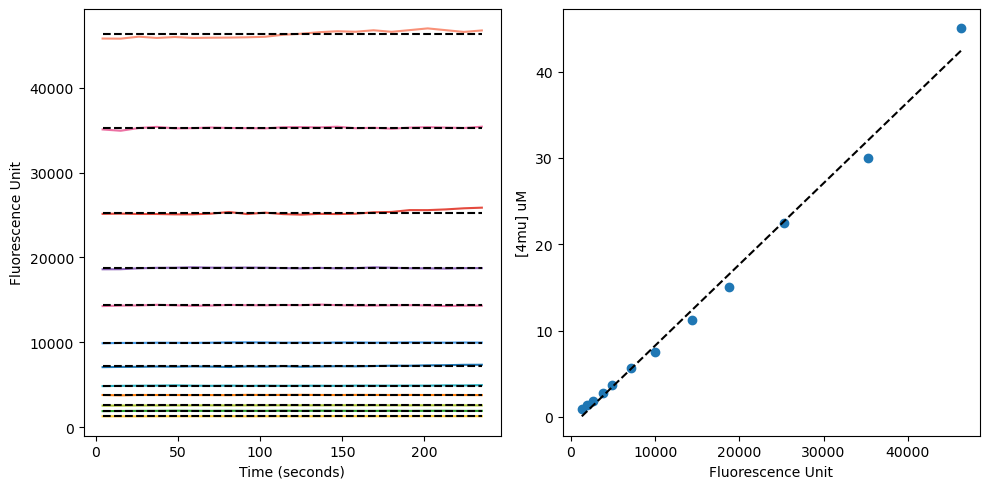


SLOPE_4MU_250401 (derived) = 9.382717e-10 M / FU
--- 240927 replicate A ---
Slope: 1.3520814422260207e-09, Intercept: -7.584174303278907e-06


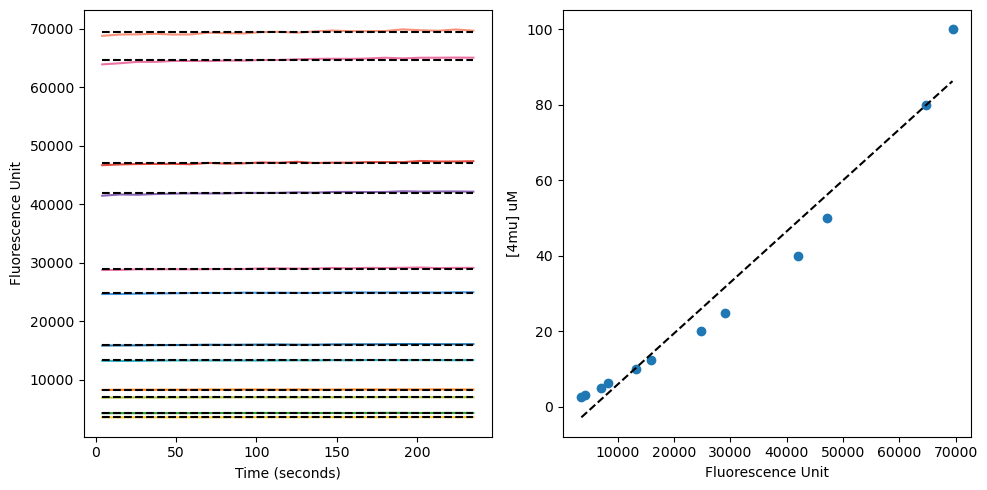

--- 240927 replicate B ---
Slope: 1.3922256043348527e-09, Intercept: -7.9007129657305e-06


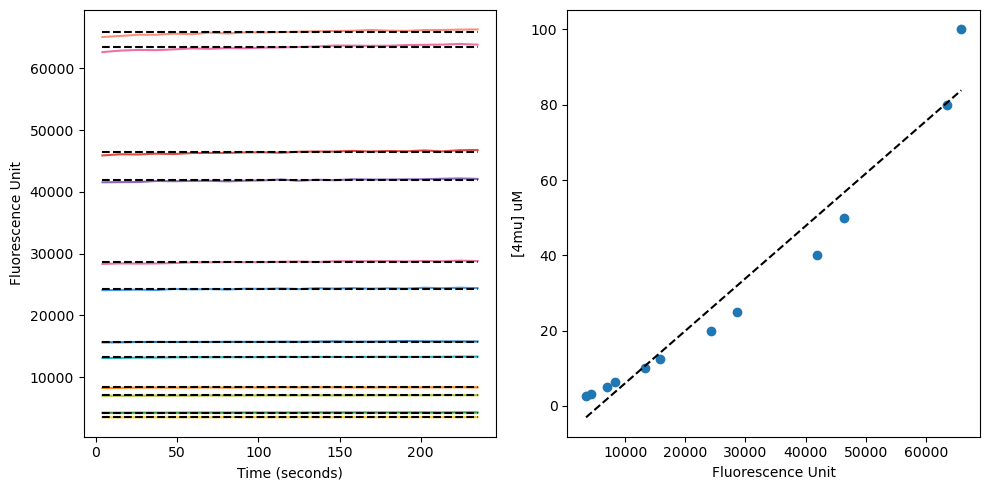

--- 240927 replicate C ---
Slope: 1.396380732487886e-09, Intercept: -7.775891055125541e-06


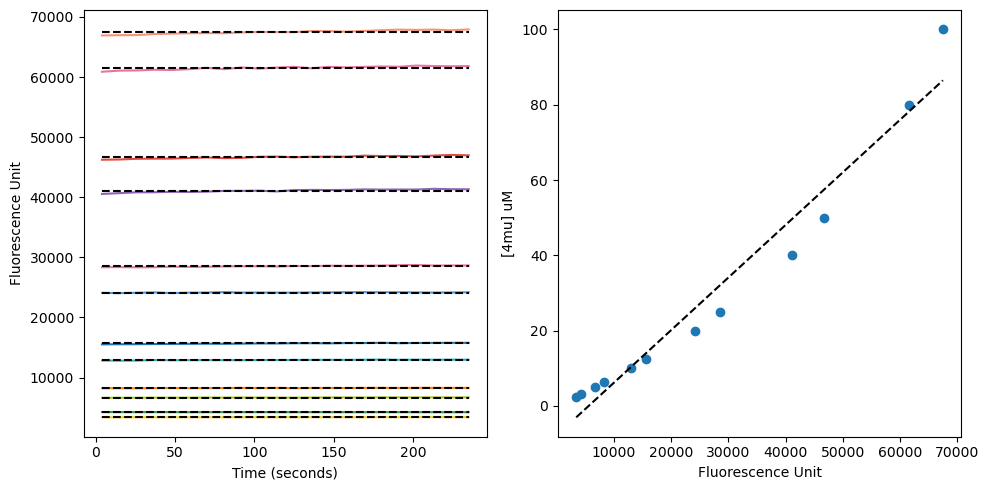


SLOPE_4MU_240927 (derived) = 1.380229e-09 M / FU
Re-derived vs deposited 240906  : 7.026228e-10 vs 7.046858e-10 (0.29 % difference)
Main kinetics calibration       : 9.382717e-10 M / FU
240927 calibration (II.IV.C)    : 1.380229e-09 M / FU


In [9]:
#############################################################
### II.I.A -- 4MU STANDARD CURVE AND CALIBRATION CONSTANTS ###
#############################################################

### Input ###
standard_curve_file = f'{raw_wetlab_data_dir}240906_a1_plus_6mutants_AND_standard_curve___1pt8_uM_4muPA_100nM_enz_25C_1hr.xlsx'

### Plate layout ###
# Rows A-C hold the 4MU dilution series in triplicate; the plate was read
# transposed, so column and row labels are swapped back before fitting.
standard_rows      = "ABC"
standard_col_range = (1, 7)
pro_concs          = [2, 1.5, 1, 0.75, 0.5, 0.375, 0.1875]   # uM 4MU
Max_FU             = 100000                                   # discard saturated wells
cutoff_start_time  = 0
cutoff_end_time    = 50000

rows, cols = list("ABCDEFG"), [1, 2, 3, 4, 5, 6, 7]
transpose_dic = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7,
                 5: "A", 6: "B", 7: "C", 1: "D", 2: "E", 3: "F", 4: "G"}
rename_dic = {}
for key, value in transpose_dic.items():
    if key in rows:
        for col in cols:
            rename_dic[f"{key}{col}"] = f"{transpose_dic[col]}{value}"
    elif key in cols:
        for row in rows:
            rename_dic[f"{row}{key}"] = f"{value}{transpose_dic[row]}"

### Fit one standard curve per replicate row ###
active_wells = [f"{r}{c}" for r in standard_rows
                for c in range(standard_col_range[0], standard_col_range[1] + 1)]
standard_data = parse_kinetics(standard_curve_file, active_wells, start_row=48)
standard_data = standard_data.rename(columns=rename_dic)

derived_slopes = []
for standard_row in standard_rows:
    print(f"--- replicate row {standard_row} ---")
    _, _, _slope = standard_curve(standard_data, standard_row, standard_col_range,
                                  Max_FU, pro_concs, cutoff_start_time, cutoff_end_time)
    derived_slopes.append(_slope)

SLOPE_4MU_DERIVED = np.average(derived_slopes)
print(f"\nDerived from the shipped plate : {SLOPE_4MU_DERIVED:.6e} M / FU")


###############################################################
### THE AUTHORITATIVE CALIBRATION (2025-04-01, pH 8)         ###
### Derived here, not pasted. This is the slope applied to    ###
### every Michaelis-Menten series reported in the manuscript. ###
###############################################################

# Two serial ladders on one plate -- 30 uM in columns 1-6 and 45 uM in columns
# 7-12 -- fitted together as a single twelve-point curve, in triplicate (rows D, E, F).
slope_250401_file      = f'{raw_wetlab_data_dir}250401_4mu_standard_curves_100uL_30uMladder_and_45uMladder_25C_5prctDMSO__pH8.xlsx'
slope_250401_rows      = "DEF"
slope_250401_cols      = (1, 12)
slope_250401_pro_concs = [30, 15, 7.5, 3.75, 1.875, 0.9375,
                          45, 22.5, 11.25, 5.625, 2.8125, 1.40625]   # uM 4MU
slope_250401_max_fu    = 250000

_active = [f"{r}{c}" for r in slope_250401_rows
           for c in range(slope_250401_cols[0], slope_250401_cols[1] + 1)]
_kd_250401 = parse_kinetics(slope_250401_file, _active, start_row=48)

_slopes_250401 = []
for _row in slope_250401_rows:
    print(f"--- 250401 replicate row {_row} ---")
    _, _, _s = standard_curve(_kd_250401, _row, slope_250401_cols, slope_250401_max_fu,
                              slope_250401_pro_concs, cutoff_start_time, cutoff_end_time)
    _slopes_250401.append(_s)

SLOPE_4MU_250401 = np.average(_slopes_250401)
print(f"\nSLOPE_4MU_250401 (derived) = {SLOPE_4MU_250401:.6e} M / FU")

###############################################################
### THE 2024-09-27 CALIBRATION                               ###
### Also derived, not pasted. Used by the A1 H130A mutant    ###
### kinetics in II.IV.C.                                     ###
###############################################################

# This plate holds two ladders read DOWN the rows -- 80 uM in plate columns 1-3
# and 100 uM in plate columns 4-6, three replicates each. standard_curve() walks
# ACROSS columns, so the plate is transposed first: the renamed row A becomes
# {plate column 1 down rows A-F} + {plate column 4 down rows A-F}, i.e. one
# twelve-point curve. Renamed rows B and C are the other two replicates.
slope_240927_file      = f'{raw_wetlab_data_dir}240927_4mu_standard_curves_25C_5dmso_95akta_80uMLadderLEFT3_100uMLadderRIGHT3.xlsx'
slope_240927_pro_concs = [80, 40, 20, 10, 5, 2.5,
                          100, 50, 25, 12.5, 6.25, 3.125]   # uM 4MU
slope_240927_max_fu    = 100000

_tp = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, 1: "A", 2: "B", 3: "C"}
_rename = {}
for _k, _v in _tp.items():
    if _k in list("ABCDEF"):
        for _c in (1, 2, 3):
            _rename[f"{_k}{_c}"] = f"{_tp[_c]}{_v}"
    elif _k in (1, 2, 3):
        for _r in "ABCDEF":
            _rename[f"{_r}{_k}"] = f"{_v}{_tp[_r]}"
for _c in (4, 5, 6):
    for _r in "ABCDEF":
        _rename[f"{_r}{_c}"] = f"{'ABC'[_c - 4]}{_tp[_r] + 6}"

_active = [f"{r}{c}" for r in "ABC" for c in range(1, 13)]
_kd_240927 = parse_kinetics(slope_240927_file, _active, start_row=48).rename(columns=_rename)

_slopes_240927 = []
for _row in "ABC":
    print(f"--- 240927 replicate {_row} ---")
    _, _, _s = standard_curve(_kd_240927, _row, (1, 12), slope_240927_max_fu,
                              slope_240927_pro_concs, cutoff_start_time, cutoff_end_time)
    _slopes_240927.append(_s)

SLOPE_4MU_240927 = np.average(_slopes_240927)
print(f"\nSLOPE_4MU_240927 (derived) = {SLOPE_4MU_240927:.6e} M / FU")

###############################################################
### CALIBRATION CONSTANTS USED THROUGHOUT THE REST OF THIS   ###
### NOTEBOOK. Change a value HERE, not in the analysis cells. ###
###############################################################

# SLOPE_4MU_250401 is derived above from the deposited 2025-04-01 plate.

# A1 knockout screen. This is the calibration measured on the 240906 plate above,
# i.e. the one this notebook can and does re-derive.
SLOPE_4MU_240906 = np.average([6.857301209337525e-10, 7.101340604738747e-10, 7.18193078001004e-10])

# SLOPE_4MU_240927 is derived above from the deposited 2024-09-27 plate.


print(f"Re-derived vs deposited 240906  : {SLOPE_4MU_DERIVED:.6e} vs {SLOPE_4MU_240906:.6e} "
      f"({100 * abs(SLOPE_4MU_DERIVED - SLOPE_4MU_240906) / SLOPE_4MU_240906:.2f} % difference)")
print(f"Main kinetics calibration       : {SLOPE_4MU_250401:.6e} M / FU")
print(f"240927 calibration (II.IV.C)    : {SLOPE_4MU_240927:.6e} M / FU")


### II.I.B. Background Reaction Rate for 4MU-PA Hydrolysis (*k*<sub>uncat</sub>)

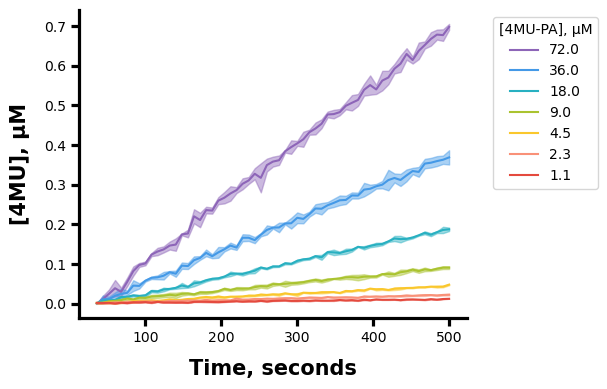

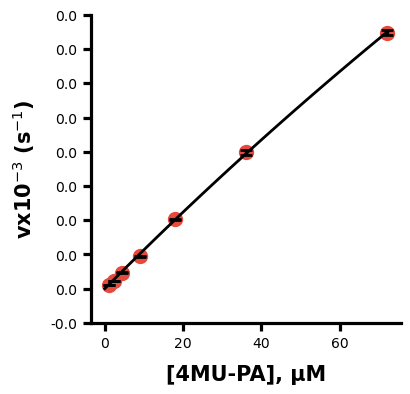

kuncat: 2.095037620962549e-05
coefficients: [2.09503762e-05 7.66075453e-12]


In [10]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250415_BLANK_kuncat_experiment__phenylacetate_subst_25C_1hour_no_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 1e6 #
rows, cols = list("ABCDEFGH"), [1,2,3,4]
replicate_dic = {1: [2, 3]}
bg_col = 4
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 30
end_time = 500
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, silent=True, ylabel="vx10$^{-3}$ (s$^{-1}$)", dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### Measuring kuncat ###
v0_list, sub_conc_list = [], []
for i, sub_conc in enumerate(sub_concs):
    v0_list.append(v0_enz[i]*1e-6*enz_conc)
    sub_conc_list.append(sub_conc*1e-6)

# Perform linear fit using NumPy's polyfit
coefficients = np.polyfit(sub_conc_list, v0_list, 1)  # 1 for linear fit
print (f"kuncat: {coefficients[0]}")
print (f"coefficients: {coefficients}")

## II.II. Michaelis-Menten Kinetics for Top 5 Design Campaign 1 Hits (5 Unique RFdiffusion2 Scaffolds)



### II.II.A. 241008 ZETA_1 (A1) Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 4μM; Temp = 25C)

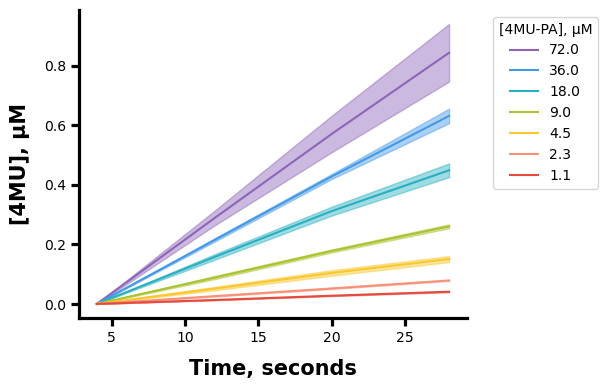

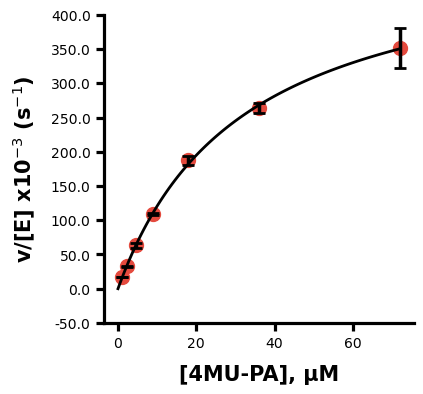

kcat:0.505797±0.030438s⁻¹
Km:31.90±4.14μM
kcat/Km: 15858.05 ± 2268.30 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.35196917579962306 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.26365435094886797 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.18773253162165834 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.10903499181441172 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.06313786725717997 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.03280041525001486 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.017162553390651397 s⁻¹


In [11]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}241008_A1_FINAL_kinetics_100nM___phenylacetate_subst_25C_5min_40x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.1
rows, cols = list("ABCDEFGH"), [1,2,3,4]
replicate_dic = {1: [2, 3]}
bg_col = 4
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 30
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.II.B. 240830 A8 Kinetics ([E]<sub>0</sub> = 2μM; [Zn(II)] = 20μM; Temp = 25C)

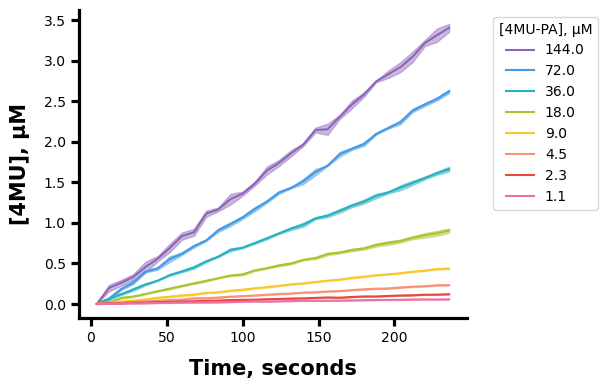

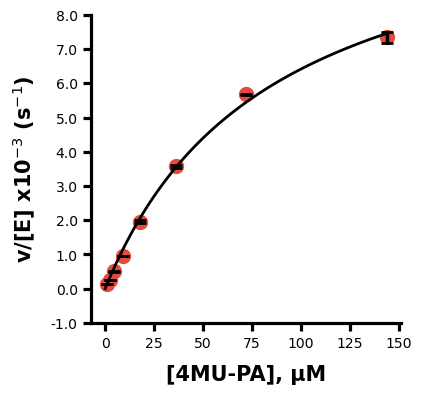

kcat:0.011844±0.000378s⁻¹
Km:84.61±5.31μM
kcat/Km: 139.99 ± 9.86 M⁻¹ s⁻¹

[SUBST] = 144.0uM, v0/[E] = 0.007340684584302558 s⁻¹
[SUBST] = 72.0uM, v0/[E] = 0.005678805169789556 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.0035785133405513776 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.0019586856847091313 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.0009589149068472354 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.0005080957012753524 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.00025251059141429325 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.00012569431567937747 s⁻¹


In [12]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}240830_A8_OFFICIAL_kinetics_2uM___phenylacetate_subst_25C_4min_10x_zn.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 2.0
rows, cols = list("ABCDEFGH"), [1,2,3,4]
replicate_dic = {1: [2, 3]}
bg_col = 4
sub_concs = np.array([144, 72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (1, 8)                                     # From 1st to 8th columns
start_time = 0
end_time = 240
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.II.C. 240830 B9 Kinetics ([E]<sub>0</sub> = 2μM; [Zn(II)] = 20μM; Temp = 25C)

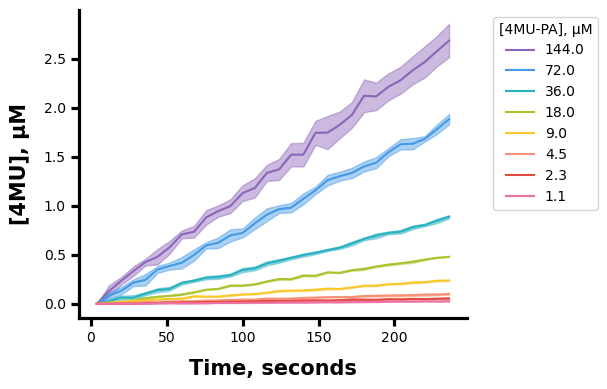

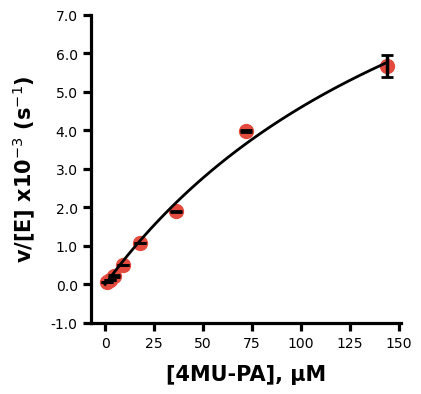

kcat:0.013617±0.001474s⁻¹
Km:196.22±32.24μM
kcat/Km: 69.40 ± 13.65 M⁻¹ s⁻¹

[SUBST] = 144.0uM, v0/[E] = 0.0056664157736723885 s⁻¹
[SUBST] = 72.0uM, v0/[E] = 0.00397767889674464 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.001900822116883578 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.0010690104988087218 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.0005077782474611885 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.00021749500084377197 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.00011902343689954889 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 5.573271345650781e-05 s⁻¹


In [13]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}240830_B9_OFFICIAL_kinetics_2uM___phenylacetate_subst_25C_4min_10x_zn.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 2.0
rows, cols = list("ABCDEFGH"), [5,6,7,8]
replicate_dic = {5: [6, 7]}
bg_col = 8
sub_concs = np.array([144, 72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (1, 8)                                     # From 1st to 8th columns
start_time = 0
end_time = 240
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.II.D. 240927 C4 Kinetics ([E]<sub>0</sub> = 3μM; [Zn(II)] = 10μM; Temp = 25C)

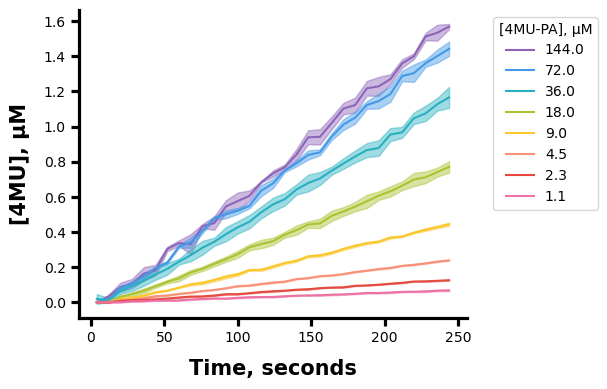

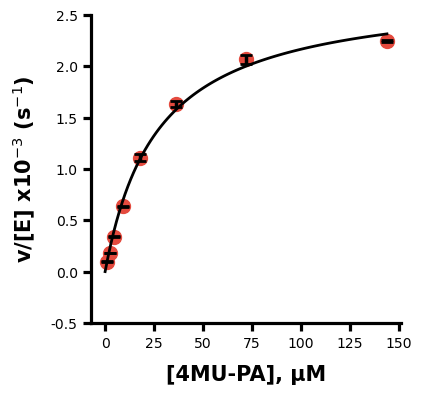

kcat:0.002747±0.000053s⁻¹
Km:26.87±1.46μM
kcat/Km: 102.24 ± 5.90 M⁻¹ s⁻¹

[SUBST] = 144.0uM, v0/[E] = 0.0022440069035292425 s⁻¹
[SUBST] = 72.0uM, v0/[E] = 0.002066063168984389 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.0016323647259654293 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.0011076188258103176 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.0006371850695323496 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.0003399711103625526 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.00018101245474843835 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 9.775765525255303e-05 s⁻¹


In [14]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}240927_C4_FINAL_kinetics_3uM___phenylacetate_subst_25C_5min_10uM_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 3.0
rows, cols = list("ABCDEFGH"), [9,10,11,12]
replicate_dic = {9: [10, 11]}
bg_col = 12
sub_concs = np.array([144, 72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (1, 8)                                     # From 1st to 8th columns
start_time = 0
end_time = 600
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.II.E. 240830 F7 Kinetics ([E]<sub>0</sub> = 2μM; [Zn(II)] = 20μM; Temp = 25C)

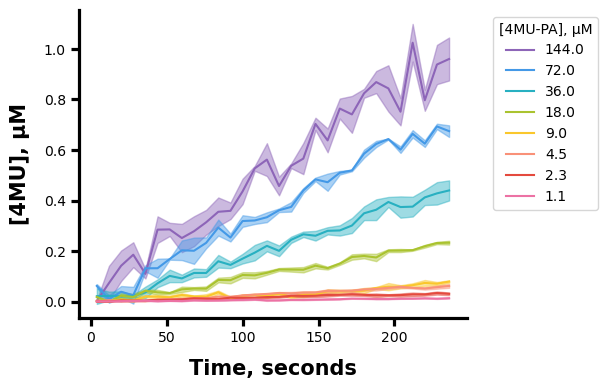

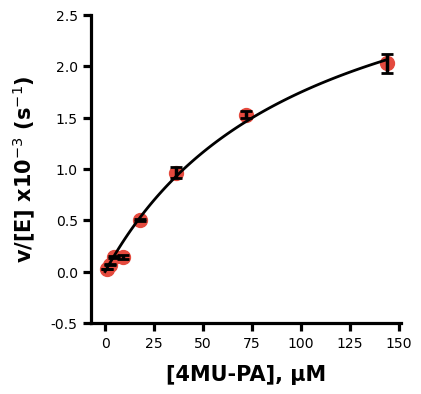

kcat:0.003515±0.000248s⁻¹
Km:101.20±13.26μM
kcat/Km: 34.73 ± 5.17 M⁻¹ s⁻¹

[SUBST] = 144.0uM, v0/[E] = 0.00202799498457413 s⁻¹
[SUBST] = 72.0uM, v0/[E] = 0.0015264310042422602 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.0009640333060153306 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.000503747018889545 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.00014171486158869203 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.0001396579348202051 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 6.850479362362418e-05 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 2.707489653403696e-05 s⁻¹


In [15]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}240830_F7_OFFICIAL_kinetics_2uM___phenylacetate_subst_25C_4min_10x_zn.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 2.0
rows, cols = list("ABCDEFGH"), [9,10,11,12]
replicate_dic = {9: [10, 11]}
bg_col = 12
sub_concs = np.array([144, 72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (1, 8)                                     # From 1st to 8th columns
start_time = 0
end_time = 240
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


## II.III. Michaelis-Menten Kinetics for Top 11 Design Campaign 2 Hits (3 Unique RFdiffusion2 Scaffolds)



### II.III.A. 250325 ZETA_2 (H10) Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 1μM; Temp = 25C)

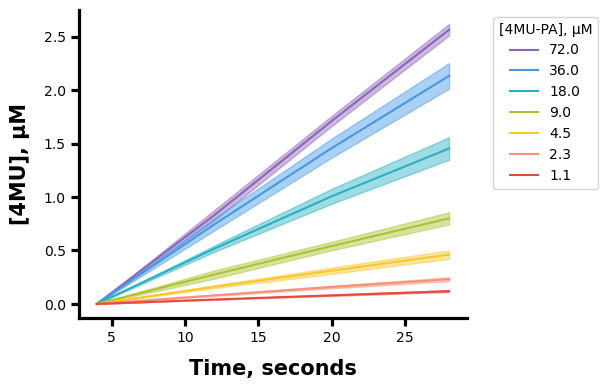

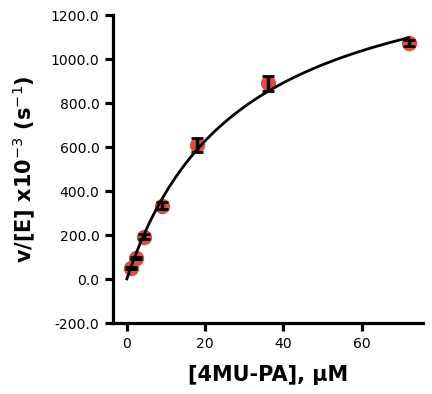

kcat:1.537782±0.061227s⁻¹
Km:28.99±2.57μM
kcat/Km: 53041.53 ± 5149.12 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 1.072522755624443 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.8895597718698904 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.606827229452599 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.3334383094962774 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.19183747035974127 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.09632922905367891 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.0496893060581274 s⁻¹


In [16]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250325_H10_1xZn_kinetics_100nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.1
rows, cols = list("ABCDEFGH"), [1,2,3,4]
replicate_dic = {1: [2, 3]}
bg_col = 4
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 30
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.B. 250318 F11 Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 1μM; Temp = 25C)

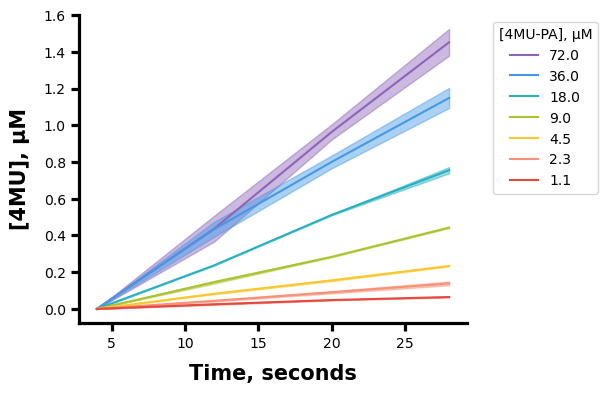

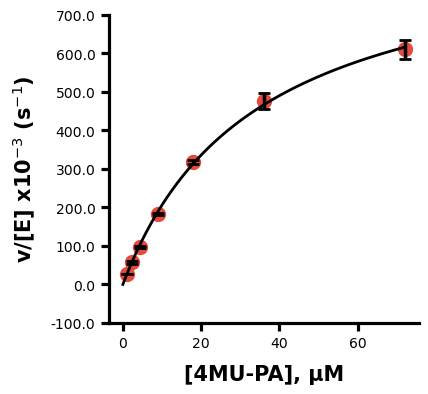

kcat:0.907012±0.033225s⁻¹
Km:33.99±2.63μM
kcat/Km: 26681.80 ± 2284.14 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.6102871063889831 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.4766420294733983 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.31754633238169927 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.18331483564638817 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.09670062827283879 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.05787963620696901 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.027151237653319806 s⁻¹


In [17]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250318_F11_1xZn_kinetics_100nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([1.3520814422260207e-09, 1.3922256043348527e-09, 1.396380732487886e-09]) # PREVIOUS ONE
#slope = np.average([1.133032096136289e-09, 1.0876356379096542e-09, 1.097352870642798e-09]) # NEW ONE
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)
enz_conc = 0.1
rows, cols = list("ABCDEFGH"), [5,6,7,8]
replicate_dic = {5: [7]}
bg_col = 8
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 30
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### II.III.C. 250327 H1 Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 1μM; Temp = 25C)

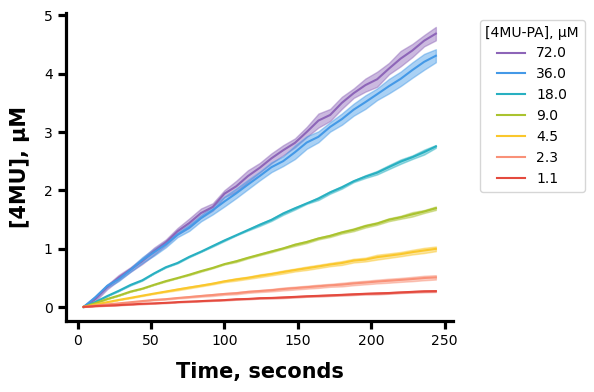

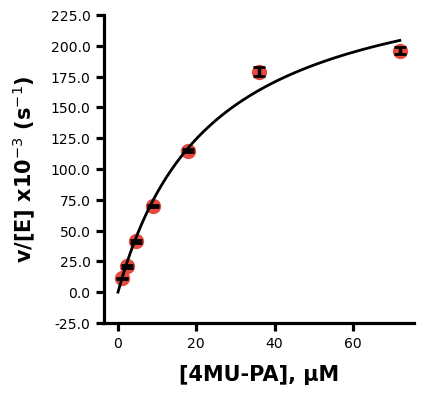

kcat:0.271458±0.010413s⁻¹
Km:23.67±2.15μM
kcat/Km: 11469.82 ± 1132.51 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.19611581280795823 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.1789404905986515 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.11494096454184166 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.06997549082723935 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.04119457357813224 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.020985789919634682 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.011284482896579373 s⁻¹


In [18]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_H1_1xZn_kinetics_100nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.1
rows, cols = list("ABCDEFGH"), [1,2,3,4]
replicate_dic = {1: [2, 3]}
bg_col = 4
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 1200
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.D. 250327 F8 Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 1μM; Temp = 25C)

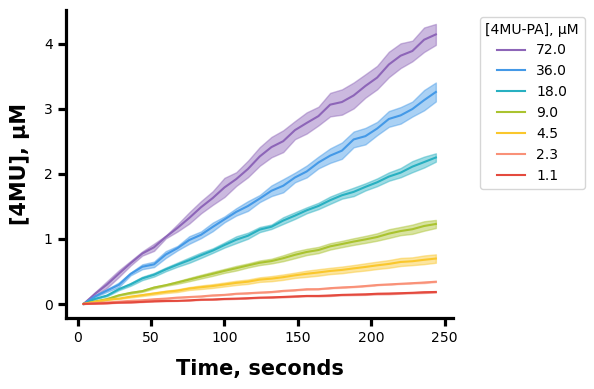

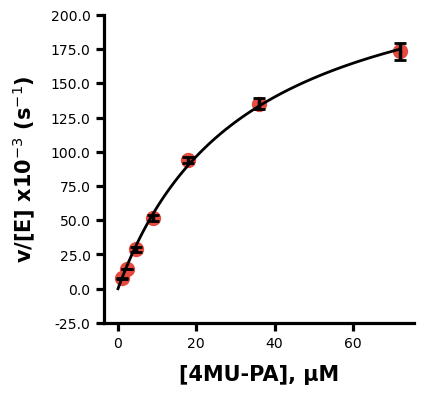

kcat:0.254271±0.009192s⁻¹
Km:32.64±2.53μM
kcat/Km: 7789.87 ± 665.23 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.17332536318503733 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.1351926262086633 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.09401854579627418 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.05170488772883123 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.02875096569917485 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.014247637023297672 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.007678001005263674 s⁻¹


In [19]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_F8_1xZn_kinetics_100nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.1
rows, cols = list("ABCDEFGH"), [5,6,7,8]
replicate_dic = {5: [6, 7]}
bg_col = 8
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 1200
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.E. 250327 F2 Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 1μM; Temp = 25C) 

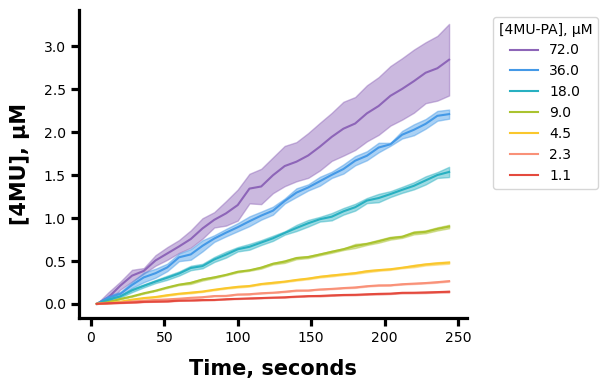

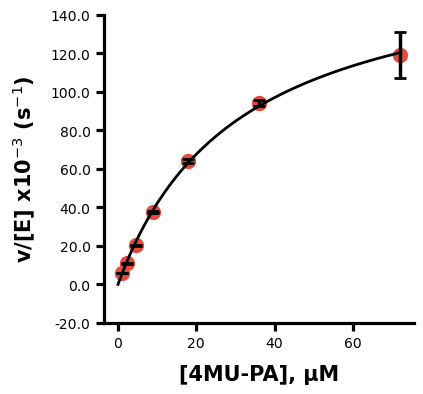

kcat:0.172024±0.011713s⁻¹
Km:30.90±4.58μM
kcat/Km: 5567.86 ± 908.76 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.11931310263326755 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.09418990018983393 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.0642927359666729 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.03778088508453834 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.02039479854755047 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.01097298677728399 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.005915431111619091 s⁻¹


In [20]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_F2_1xZn_kinetics_100nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.1
rows, cols = list("ABCDEFGH"), [5,6,7,8]
replicate_dic = {5: [6, 7]}
bg_col = 8
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 1200
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.F. 250327 F7 Kinetics ([E]<sub>0</sub> = 500nM; [Zn(II)] = 5μM; Temp = 25C) (BONUS DATA)

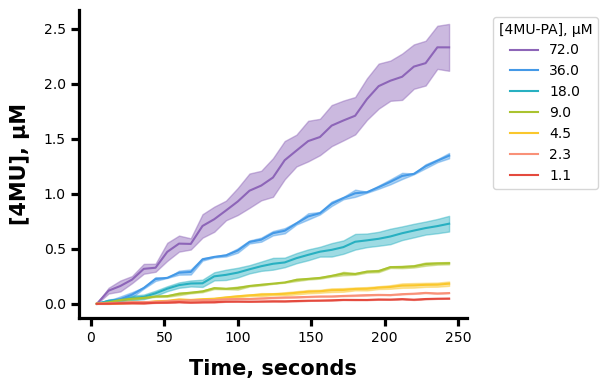

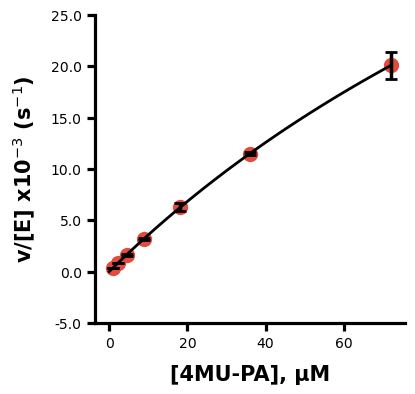

kcat:0.078882±0.017701s⁻¹
Km:210.80±59.93μM
kcat/Km: 374.20 ± 135.53 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.020083365484149684 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.011483550355813289 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.006308647670308569 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.0031445974634131276 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.001615618131292785 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.0008048454386004646 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.00038514540418141944 s⁻¹


In [21]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_F7_1xZn_kinetics_500nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.5
rows, cols = list("ABCDEFGH"), [5,6,7,8]
replicate_dic = {5: [6, 7]}
bg_col = 8
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 1200
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.G. 250318 ZETA_3 (H6) Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 1μM; Temp = 25C)

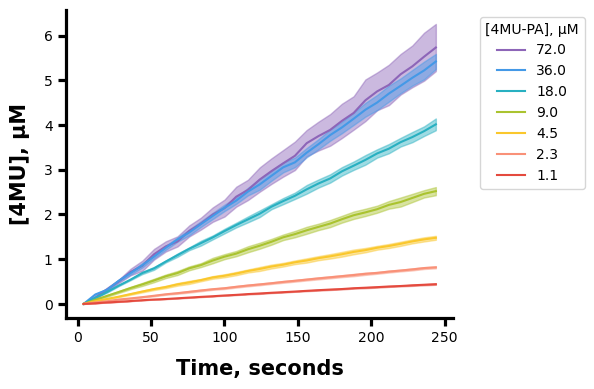

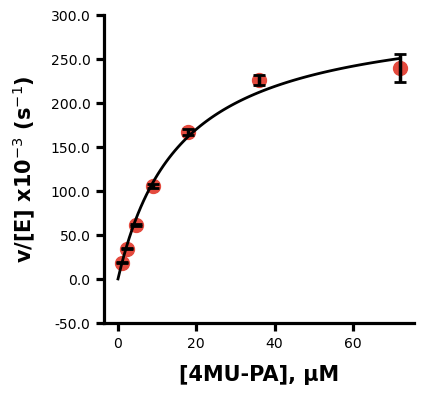

kcat:0.306310±0.012562s⁻¹
Km:16.02±1.76μM
kcat/Km: 19119.02 ± 2236.76 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.2398305728532845 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.2261387735408347 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.16688893274433356 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.10550843326949418 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.06137056817144082 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.034056015751122014 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.01845945550271776 s⁻¹


In [22]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250318_H6_1xZn_kinetics_100nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.1
rows, cols = list("ABCDEFGH"), [5,6,7,8]
replicate_dic = {5: [6, 7]}
bg_col = 8
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 1200
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.H. 250318 B10 Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 1μM; Temp = 25C)

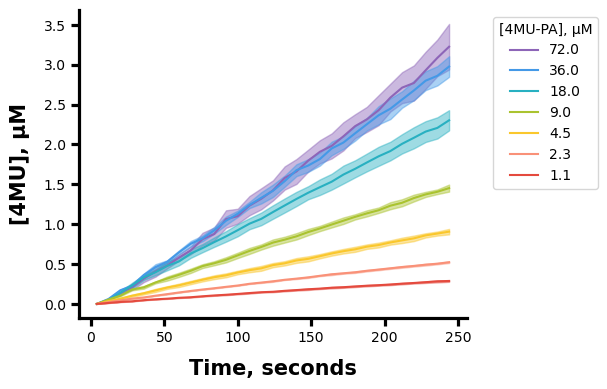

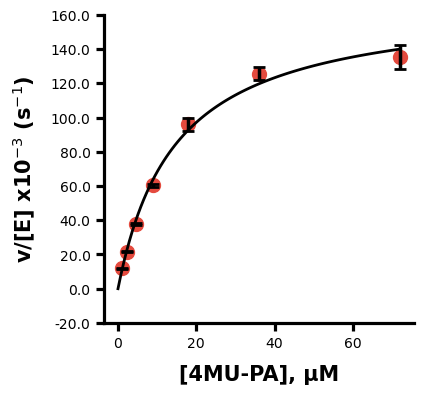

kcat:0.168582±0.005733s⁻¹
Km:14.70±1.37μM
kcat/Km: 11472.02 ± 1137.99 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.13528011626241276 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.1254988858929593 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.09612051404257206 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.0603170618125081 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.03767841925582275 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.02152696713498947 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.011931594014852429 s⁻¹


In [23]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250318_B10_1xZn_kinetics_100nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([1.3520814422260207e-09, 1.3922256043348527e-09, 1.396380732487886e-09]) # PREVIOUS ONE
#slope = np.average([1.133032096136289e-09, 1.0876356379096542e-09, 1.097352870642798e-09]) # NEW ONE
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)
enz_conc = 0.1
rows, cols = list("ABCDEFGH"), [5,6,7,8]
replicate_dic = {5: [6, 7]}
bg_col = 8
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 600
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### II.III.I. 250327 B5 Kinetics ([E]<sub>0</sub> = 500nM; [Zn(II)] = 5μM; Temp = 25C)

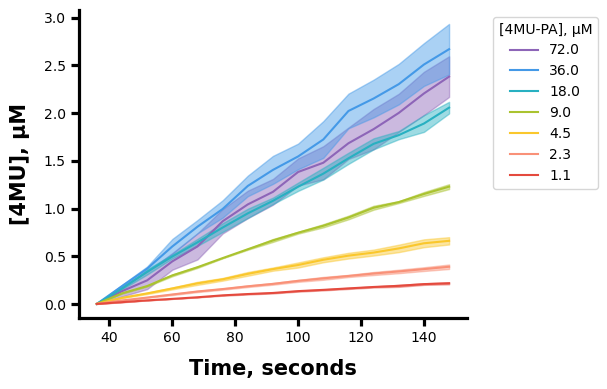

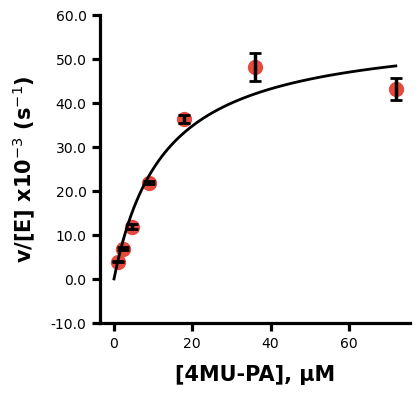

kcat:0.057023±0.003754s⁻¹
Km:12.81±2.40μM
kcat/Km: 4450.40 ± 884.89 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.04308677738307758 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.048145904942114855 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.0363728289422798 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.02189021412777681 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.011874722101920926 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.006892108366981242 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.003870929305258862 s⁻¹


In [24]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_B5_1xZn_kinetics_500nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.5
rows, cols = list("ABCDEFGH"), [9,10,11,12]
replicate_dic = {9: [10, 11]}
bg_col = 12
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 30
end_time = 150
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.J. 250327 D9 Kinetics ([E]<sub>0</sub> = 500nM; [Zn(II)] = 5μM; Temp = 25C) 

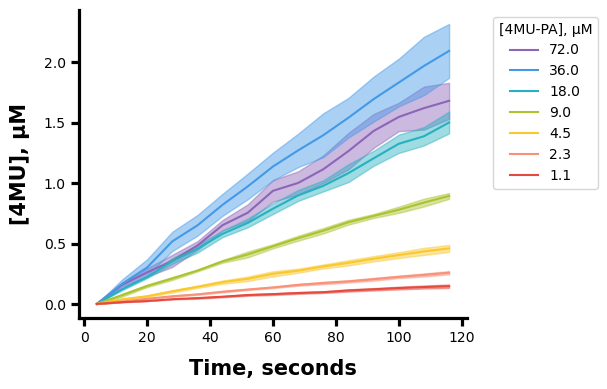

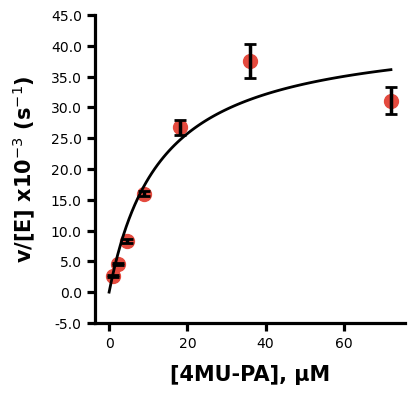

kcat:0.042745±0.003550s⁻¹
Km:13.22±3.10μM
kcat/Km: 3233.26 ± 804.53 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.031074386247287616 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.03747976616389618 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.02673208710598222 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.016005630860591702 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.008304542389921607 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.004558436732004448 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.0026098474453144804 s⁻¹


In [25]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_D9_1xZn_kinetics_500nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.5
rows, cols = list("ABCDEFGH"), [9,10,11,12]
replicate_dic = {9: [10, 11]}
bg_col = 12
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 120
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.K. 250327 F12 Kinetics ([E]<sub>0</sub> = 500nM; [Zn(II)] = 5μM; Temp = 25C) 

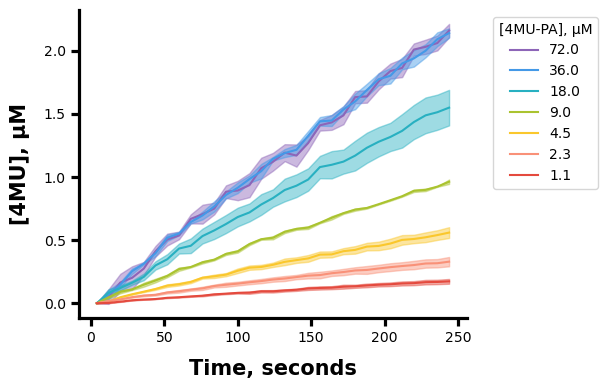

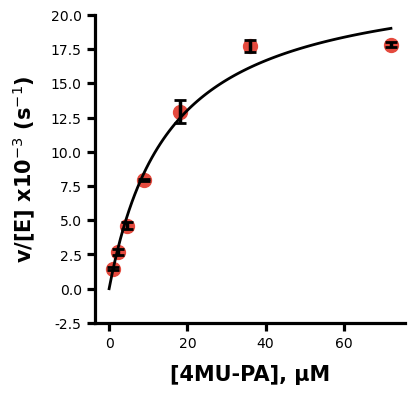

kcat:0.023096±0.001007s⁻¹
Km:15.44±1.82μM
kcat/Km: 1495.75 ± 187.81 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.017838733276332383 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.017732168814468173 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.012936200527527341 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.00792767081990944 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.004586023685889414 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.0026850776315578413 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.0014519880848208166 s⁻¹


In [26]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_F12_1xZn_kinetics_500nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.5
rows, cols = list("ABCDEFGH"), [9,10,11,12]
replicate_dic = {9: [10, 11]}
bg_col = 12
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 1200
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.L. 250327 C7 Kinetics ([E]<sub>0</sub> = 500nM; [Zn(II)] = 5μM; Temp = 25C) (BONUS DATA)

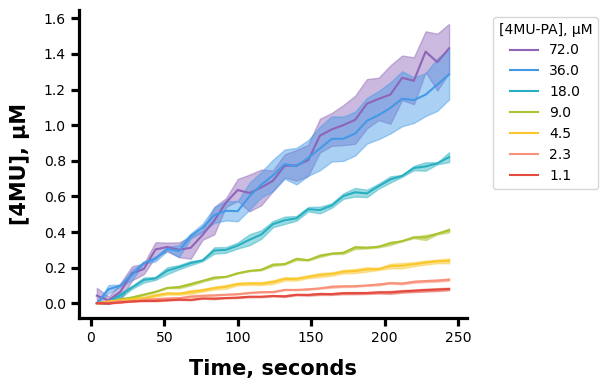

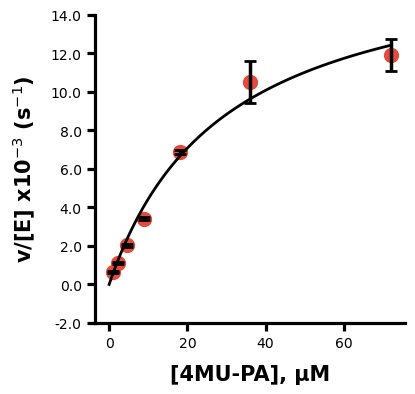

kcat:0.017505±0.001494s⁻¹
Km:29.43±5.56μM
kcat/Km: 594.75 ± 123.31 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.011921347431980872 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.010502085356454449 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.006876339889340221 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.0034176610149533435 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.002027782986307822 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.0011031628759256601 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.000640900112655525 s⁻¹


In [27]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_C7_1xZn_kinetics_500nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.5
rows, cols = list("ABCDEFGH"), [9,10,11,12]
replicate_dic = {9: [10, 11]}
bg_col = 12
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 1200
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


### II.III.M. 250327 ZETA_4 (C5) Kinetics ([E]<sub>0</sub> = 500nM; [Zn(II)] = 5μM; Temp = 25C)

The fitted substrate range is 1.1–72 μM, matching Supplementary Methods §4.3;
the 144 μM wells remain in the raw data but are excluded from this published fit.

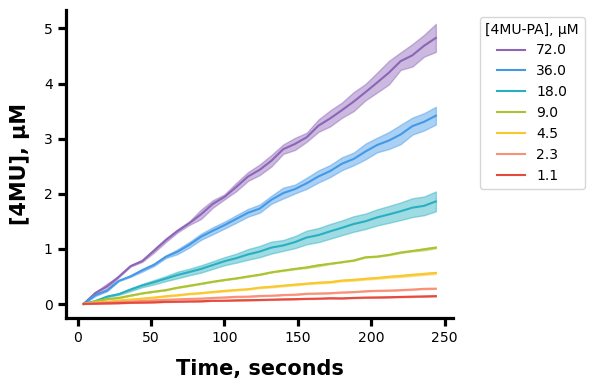

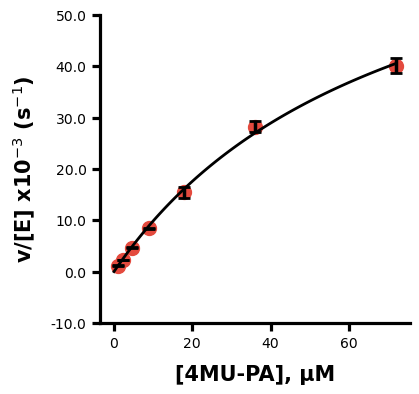

kcat:0.081466±0.005933s⁻¹
Km:72.71±8.77μM
kcat/Km: 1120.42 ± 157.90 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.04012167753161181 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.028213887116968688 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.015482176855610362 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.008455953104819712 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.004670487056698355 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.002279628229317087 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.001164831540838795 s⁻¹


In [28]:
### Input/Output File/Directory ###
excel_file = f'{raw_wetlab_data_dir}250327_C5_1xZn_kinetics_500nM___phenylacetate_subst_25C_5min_10x_zn_144uMsubstLadder.xlsx'
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)

### Input Parameter ###
#slope = np.average([9.710399908638067e-10, 9.561887458844373e-10, 9.695313428289856e-10]) # NEW ONE - After removing the last two points
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

enz_conc = 0.5
rows, cols = list("ABCDEFGH"), [1,2,3,4]
replicate_dic = {1: [2, 3]}
bg_col = 4
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])              #[144, 72, 36, 18, 9, 4.5, 2.25, 1.125]
col_range_to_analyze = (2, 8)                                     # From 2nd to 8th columns
start_time = 0
end_time = 1200
substrate_name = '4MU-PA'

### Parameter Preprocessing ###
transpose_dic = make_transpose_dic(rows, cols)
rename_dic = make_rename_dic(transpose_dic, rows, cols)
represent_row = "A"
replicate_rows = ["ABCDEFGHIJKL"[cols.index(rep)] for rep in list(replicate_dic.values())[0]]
bg_row = "ABCDEFGHIJKL"[cols.index(bg_col)]
row_column_ranges = {represent_row: col_range_to_analyze}
active_wells = make_active_wells(row_column_ranges)

### Data Parsing/Plotting ###
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, rows, cols, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)


## II.IV. Michaelis-Menten Kinetics for ZETA_1 Mutants (Knockouts) with Activity


### II.IV.A. 241008 ZETA_1 (A1; Design Campaign 1) **D67A Mutant** Kinetics ([E]<sub>0</sub> = 100nM; [Zn(II)] = 4μM; Temp = 25C)

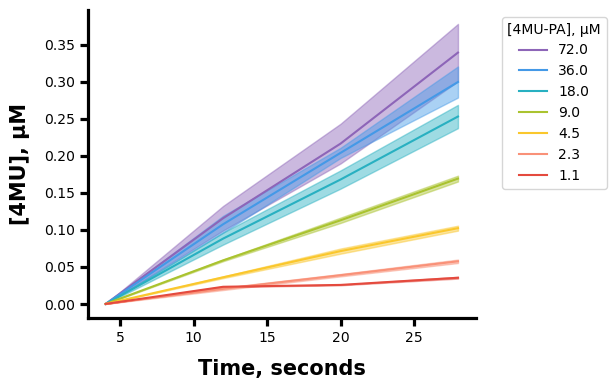

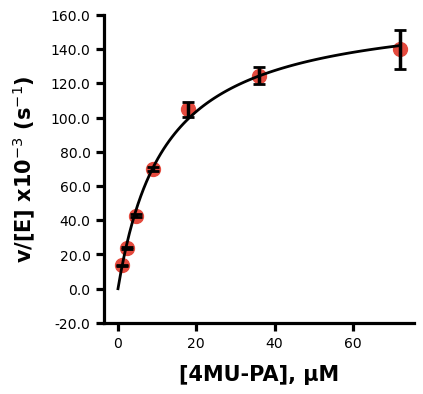

kcat:0.165780±0.006424s⁻¹
Km:12.02±1.35μM
kcat/Km: 13792.67 ± 1640.23 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.13984157967735775 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.12439919109123632 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.104851863767032 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.07021399974854194 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.04276955218535906 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.023886833990177686 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.013565845162997804 s⁻¹


[np.float64(0.13984157967735775),
 np.float64(0.12439919109123632),
 np.float64(0.104851863767032),
 np.float64(0.07021399974854194),
 np.float64(0.04276955218535906),
 np.float64(0.023886833990177686),
 np.float64(0.013565845162997804)]

In [29]:
# excel file output from neo2
excel_file = f'{raw_wetlab_data_dir}241008_A1_D67A_FINAL_kinetics_100nM___phenylacetate_subst_25C_5min_40x_zn_144uMsubstLadder.xlsx'

# Standarization slope
#slope = np.average([1.3520814422260207e-09, 1.3922256043348527e-09, 1.396380732487886e-09])
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

# Time to investigate
start_time = 0
end_time = 30

# What substrate did you use? Important for normalization and for pretty (and accurate) plots.
substrate_name = '4MU-PA'

# - what enzyme concentration did you test? (μΜ) - #
enz_conc = 0.1

# Well information
rows, cols = list("ABCDEFGH"), [9,10,11,12]

# Transpose information
transpose_dic = {"A": 1, 
                 "B": 2,
                 "C": 3,
                 "D": 4,
                 "E": 5,
                 "F": 6,
                 "G": 7,
                 "H": 8,
                 9: "A",
                 10: "B",
                 11: "C",
                 12: "D",
                 }

# make a directory for cute pics
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)


rename_dic = {}
for key in transpose_dic:
    value = transpose_dic[key]
    if key in rows:
        for col in cols:
            rename_dic[f"{key}{col}"] = f"{transpose_dic[col]}{value}"
    elif key in cols:
        for row in rows:
            rename_dic[f"{row}{key}"] = f"{value}{transpose_dic[row]}"

# specify rows and columns where measurements were taken
row_column_ranges = {
    #'A': (1, 8),
    'A': (2, 8),
}

# rows containing replicates
replicate_rows = ['B', 'C']
#replicate_rows = []

# Create an empty list to store active wells
active_wells = []

# Iterate through rows/columns, append to active wells
for row, (start_col, end_col) in row_column_ranges.items():
    for col in range(start_col, end_col + 1):
        active_wells.append(f"{row}{col}")

# - what substrate concentrations did you test in those specific wells? (μM) - #
#sub_concs = np.array([144, 72, 36, 18, 9, 4.5, 2.25, 1.125])
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])

# which row is background?
bg_row = 'D'

# plotting stuff
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
mm_kinetics(kinetic_data, bn, None, None, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### II.IV.B. 240927 ZETA_1 (A1; Design Campaign 1) **N17A Mutant** Kinetics ([E]<sub>0</sub> = 500nM; [Zn(II)] = 20μM; Temp = 25C)

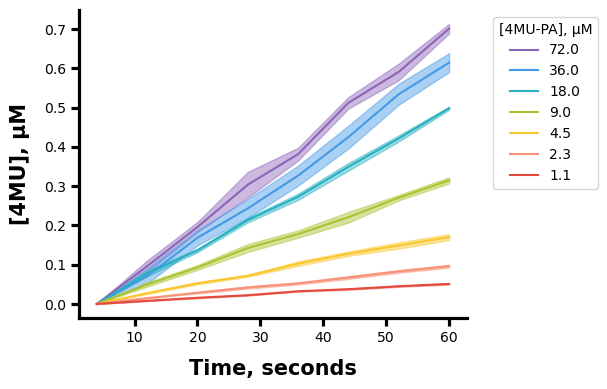

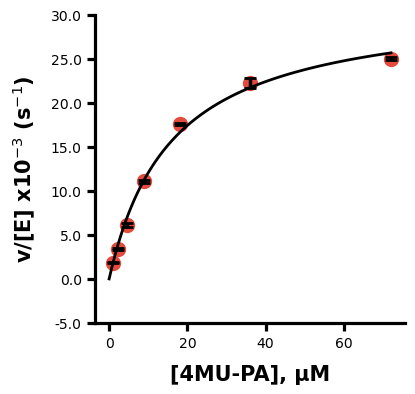

kcat:0.031400±0.000734s⁻¹
Km:16.01±1.00μM
kcat/Km: 1961.07 ± 130.86 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.025033610526531008 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.022234619418727078 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.01758421716578781 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.011093573669041295 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.006120175102697305 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.0033919267033047894 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.0018411720689179123 s⁻¹


[np.float64(0.025033610526531008),
 np.float64(0.022234619418727078),
 np.float64(0.01758421716578781),
 np.float64(0.011093573669041295),
 np.float64(0.006120175102697305),
 np.float64(0.0033919267033047894),
 np.float64(0.0018411720689179123)]

In [30]:
# excel file output from neo2
excel_file = f'{raw_wetlab_data_dir}240927_A1_N17A_FINAL_kinetics_500nM___phenylacetate_subst_25C_5min_40x_zn_144uMsubstLadder.xlsx'

# Standarization slope
#slope = np.average([1.3520814422260207e-09, 1.3922256043348527e-09, 1.396380732487886e-09])
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

# Time to investigate
start_time = 0
end_time = 60

# What substrate did you use? Important for normalization and for pretty (and accurate) plots.
substrate_name = '4MU-PA'

# - what enzyme concentration did you test? (μΜ) - #
enz_conc = 0.5

# Well information
rows, cols = list("ABCDEFGH"), [5,6,7,8]

# Transpose information
transpose_dic = {"A": 1, 
                 "B": 2,
                 "C": 3,
                 "D": 4,
                 "E": 5,
                 "F": 6,
                 "G": 7,
                 "H": 8,
                 5: "A",
                 6: "B",
                 7: "C",
                 8: "D",
                 }

# make a directory for cute pics
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)


rename_dic = {}
for key in transpose_dic:
    value = transpose_dic[key]
    if key in rows:
        for col in cols:
            rename_dic[f"{key}{col}"] = f"{transpose_dic[col]}{value}"
    elif key in cols:
        for row in rows:
            rename_dic[f"{row}{key}"] = f"{value}{transpose_dic[row]}"

# specify rows and columns where measurements were taken
row_column_ranges = {
    #'A': (1, 8),
    'A': (2, 8),
}

# rows containing replicates
replicate_rows = ['B', 'C']
#replicate_rows = []

# Create an empty list to store active wells
active_wells = []

# Iterate through rows/columns, append to active wells
for row, (start_col, end_col) in row_column_ranges.items():
    for col in range(start_col, end_col + 1):
        active_wells.append(f"{row}{col}")

# - what substrate concentrations did you test in those specific wells? (μM) - #
#sub_concs = np.array([144, 72, 36, 18, 9, 4.5, 2.25, 1.125])
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])

# which row is background?
bg_row = 'D'

# plotting stuff
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
mm_kinetics(kinetic_data, bn, None, None, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.01, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### II.IV.C. 240927 ZETA_1 (A1; Design Campaign 1) **H130A Mutant** Kinetics ([E]<sub>0</sub> = 500nM; [Zn(II)] = 20μM; Temp = 25C)

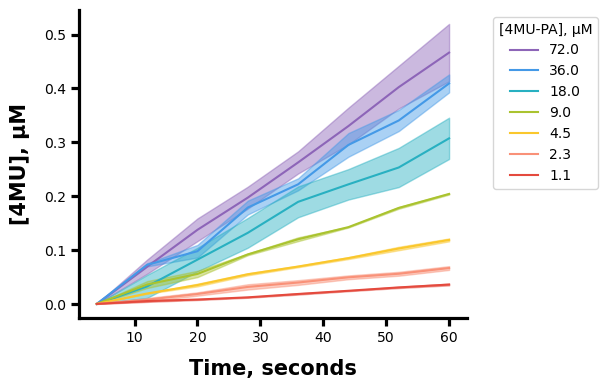

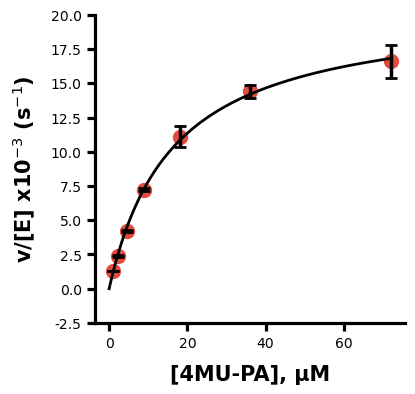

kcat:0.020640±0.000862s⁻¹
Km:16.33±1.81μM
kcat/Km: 1264.19 ± 149.88 M⁻¹ s⁻¹

[SUBST] = 72.0uM, v0/[E] = 0.016597542548470824 s⁻¹
[SUBST] = 36.0uM, v0/[E] = 0.014408241888159938 s⁻¹
[SUBST] = 18.0uM, v0/[E] = 0.011110328521033469 s⁻¹
[SUBST] = 9.0uM, v0/[E] = 0.007232511109955601 s⁻¹
[SUBST] = 4.5uM, v0/[E] = 0.004208260325367988 s⁻¹
[SUBST] = 2.3uM, v0/[E] = 0.0024052520859878085 s⁻¹
[SUBST] = 1.1uM, v0/[E] = 0.0012901236033974854 s⁻¹


[np.float64(0.016597542548470824),
 np.float64(0.014408241888159938),
 np.float64(0.011110328521033469),
 np.float64(0.007232511109955601),
 np.float64(0.004208260325367988),
 np.float64(0.0024052520859878085),
 np.float64(0.0012901236033974854)]

In [31]:
# excel file output from neo2
excel_file = f'{raw_wetlab_data_dir}240927_A1_H130A_FINAL_kinetics_500nM___phenylacetate_subst_25C_5min_40x_zn_144uMsubstLadder.xlsx'

# Standarization slope
slope = SLOPE_4MU_240927  # defined in II.I.A
slope = SLOPE_4MU_250401  # defined in II.I.A # NEWEST ONE (250401)

# Time to investigate
start_time = 0
end_time = 60

# What substrate did you use? Important for normalization and for pretty (and accurate) plots.
substrate_name = '4MU-PA'

# - what enzyme concentration did you test? (μΜ) - #
enz_conc = 0.5

# Well information
rows, cols = list("ABCDEFGH"), [5,6,7,8]

# Transpose information
transpose_dic = {"A": 1, 
                 "B": 2,
                 "C": 3,
                 "D": 4,
                 "E": 5,
                 "F": 6,
                 "G": 7,
                 "H": 8,
                 5: "A",
                 6: "B",
                 7: "C",
                 8: "D",
                 }

# make a directory for cute pics
pics_dir = wetlab_data_plots_dir  # figures go to wetlab_data_plots/ (created by setup_directories)


rename_dic = {}
for key in transpose_dic:
    value = transpose_dic[key]
    if key in rows:
        for col in cols:
            rename_dic[f"{key}{col}"] = f"{transpose_dic[col]}{value}"
    elif key in cols:
        for row in rows:
            rename_dic[f"{row}{key}"] = f"{value}{transpose_dic[row]}"

# specify rows and columns where measurements were taken
row_column_ranges = {
    #'A': (1, 8),
    'A': (2, 8),
}

# rows containing replicates
replicate_rows = ['B', 'C']
#replicate_rows = []

# Create an empty list to store active wells
active_wells = []

# Iterate through rows/columns, append to active wells
for row, (start_col, end_col) in row_column_ranges.items():
    for col in range(start_col, end_col + 1):
        active_wells.append(f"{row}{col}")

# - what substrate concentrations did you test in those specific wells? (μM) - #
#sub_concs = np.array([144, 72, 36, 18, 9, 4.5, 2.25, 1.125])
sub_concs = np.array([72, 36, 18, 9, 4.5, 2.3, 1.1])

# which row is background?
bg_row = 'D'

# plotting stuff
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
mm_kinetics(kinetic_data, bn, None, None, active_wells, bg_row, enz_conc, sub_concs, substrate_name, pics_dir, replicate_rows, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.01, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

# **III. Zn(II)-DEPENDENCE DATA** 

## III.I. Zn(II)-Dependent Activity Screening of ZETA_1 

### III.I.A. Reaction Progress Curves for 1.) Zn(II)-Free Enzyme, Followed by 2.) Readdition of Zn(II) to Reactions

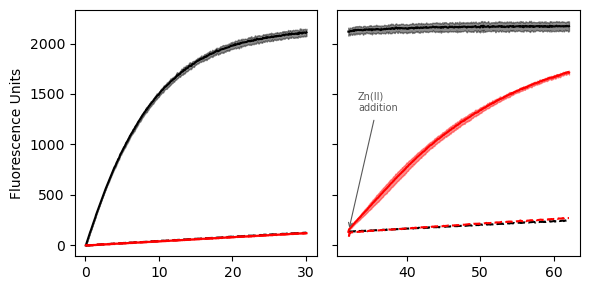

In [32]:
# excel file output from neo2
excel_file1 = f'{raw_wetlab_data_dir}240904_zn_chelation_72uM_18uM_1pt8uM_4mu_PositiveTopRow_ChelatedBottomRow_30min_25C_pt1_BEFORE_100uM_zn.xlsx'
excel_file2 = f'{raw_wetlab_data_dir}240904_zn_chelation_72uM_18uM_1pt8uM_4mu_PositiveTopRow_ChelatedBottomRow_30min_25C_pt1_AFTER_100uM_zn_2min_delay.xlsx'

# Specify row and column ranges
row_column_ranges = {
    'A': (1, 12),
    'B': (1, 12),
}

# Specify replicates
replicate_dic = {
    #1: [2, 3],
    #5: [6, 7],
    9: [10, 11],
}

# Specify background
#background_col = 4
#background_col = 8
background_col = 12

# Create an empty list to store active wells
active_wells = []

# Iterate through rows/columns, append to active wells
for row, (start_col, end_col) in row_column_ranges.items():
    for col in range(start_col, end_col + 1):
        active_wells.append(f"{row}{col}")


# Load data
screening_data_before_zn = parse_kinetics(excel_file1, active_wells, start_row=48)
screening_data_after_zn = parse_kinetics(excel_file2, active_wells, start_row=48)

# Standardize
"""
for i, df in enumerate([screening_data_before_zn, screening_data_after_zn]):
    for well in active_wells:
        fu = df[well].values
        product_concentration = fu * slope * 1000000
        df[well] = product_concentration
"""

# Zero-ing        
for well in active_wells:
    screening_data_after_zn[well] = screening_data_after_zn[well] - np.min(screening_data_before_zn[well])
    screening_data_before_zn[well] = screening_data_before_zn[well] - np.min(screening_data_before_zn[well])
    
# Convernting time
for i, df in enumerate([screening_data_before_zn, screening_data_after_zn]):
    df["Time"] = df["Time"]/60
screening_data_after_zn["Time"] = screening_data_after_zn["Time"] + 32

fig, axes = plt.subplots(1, 2, figsize=(6,3))
for representive_col in replicate_dic:
    replicates = [representive_col]
    replicates.extend(replicate_dic[representive_col])
    
    for row, name, color in zip(["A", "B"], ["WT", "Chelated"], ["black", "red"]):
        replicates_well = [f"{row}{col}" for col in replicates]
        avg_product_concentration_before_zn = np.array(screening_data_before_zn[replicates_well].mean(axis=1).tolist())
        std_product_concentration_before_zn = np.array(screening_data_before_zn[replicates_well].std(axis=1).tolist())
        
        axes[0].plot(screening_data_before_zn["Time"].values, avg_product_concentration_before_zn, color=color)
        axes[0].fill_between(screening_data_before_zn["Time"].values, 
                             avg_product_concentration_before_zn - std_product_concentration_before_zn,
                             avg_product_concentration_before_zn + std_product_concentration_before_zn,
                             color=color, alpha = 0.45)
        
        avg_product_concentration_after_zn = np.array(screening_data_after_zn[replicates_well].mean(axis=1).tolist())
        std_product_concentration_after_zn = np.array(screening_data_after_zn[replicates_well].std(axis=1).tolist())
        
        axes[1].plot(screening_data_after_zn["Time"].values, avg_product_concentration_after_zn, color=color)
        if color == "red":   # keep the chelated trace for the Zn(II) annotation below
            zn_annot_time = screening_data_after_zn["Time"].values
            zn_annot_curve = avg_product_concentration_after_zn
        axes[1].fill_between(screening_data_after_zn["Time"].values, 
                             avg_product_concentration_after_zn - std_product_concentration_after_zn,
                             avg_product_concentration_after_zn + std_product_concentration_after_zn,
                             color=color, alpha = 0.45)
        
        axes[0].plot(screening_data_before_zn["Time"].values, screening_data_before_zn[f"{row}{background_col}"], color=color, linestyle='dashed')
        axes[1].plot(screening_data_after_zn["Time"].values, screening_data_after_zn[f"{row}{background_col}"], color=color, linestyle='dashed')
    
    axes[0].set_ylim(axes[0].get_ylim()[0], axes[1].get_ylim()[1])
    axes[1].set_ylim(axes[0].get_ylim()[0], axes[1].get_ylim()[1])
    axes[1].set_yticklabels([])

    ### LABEL THE Zn(II) READDITION ON THE RIGHT-HAND PANEL ###
    # The right panel begins immediately after Zn(II) was added back, so the
    # arrow points at the START of the chelated (red) trace. The label is set on
    # two lines to keep it narrow, sits high in the panel so it never overlaps
    # the rising curve, and is gray so it reads as an annotation rather than as
    # another data series. All positions are fractions of the current axis
    # limits, so the label keeps its clearance if the data change.
    _x0, _y0 = zn_annot_time[0], zn_annot_curve[0]            # first point after Zn(II) addition
    _xlo, _xhi = axes[1].get_xlim()
    _ylo, _yhi = axes[1].get_ylim()
    _annot_grey = "0.35"
    axes[1].annotate(
        "Zn(II)\naddition",
        xy=(_x0, _y0),                                        # arrow tip: start of the red curve
        xytext=(_x0 + 0.04 * (_xhi - _xlo),                   # nudge right so the text is not clipped
                _ylo + 0.58 * (_yhi - _ylo)),                 # high enough to clear the curve
        color=_annot_grey, fontsize=7, ha="left", va="bottom", linespacing=1.2,
        arrowprops=dict(arrowstyle="->", color=_annot_grey, lw=0.8,
                        shrinkA=3, shrinkB=3),
    )

    #axes[0].set_ylabel("[4MU] (uM)")
    axes[0].set_ylabel("Fluorescence Units")
plt.tight_layout()
save_figure(f'{wetlab_data_plots_dir}zinc_chelating_progress_curves_1pt8uM_4MUPA', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()

## III.II. Dissociation Constant (K<sub>d</sub>) Measurement for Zn(II) Binding to ZETA_1 + Mutants (Knockouts)

### III.II.A. Load Data and Plot (Non-Normalized)

In [33]:
file_path = f'{raw_wetlab_data_dir}Zn-Hydrolase_binding_data.csv'
data = pd.read_csv(file_path, delimiter=',', dtype=float, na_values=['', ' '])

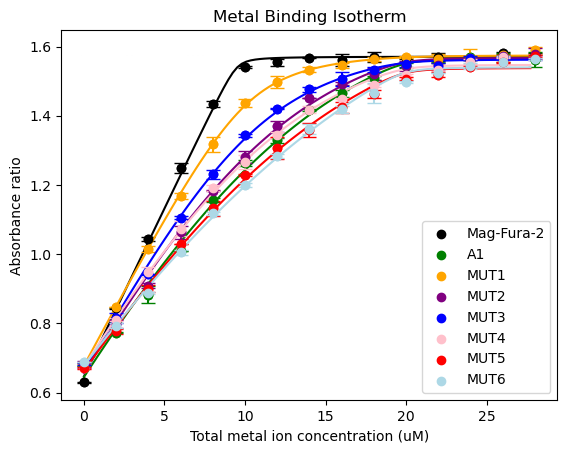

In [34]:
#Plot not normalized data

#Dye (Mag-Fura-2)
plt.figure()   # open a fresh figure so this cell does not draw onto a previous one
plt.plot(data.iloc[:, 0], data.iloc[:, 1], color='black')
plt.scatter(data.iloc[:, 2], data.iloc[:, 3], color='black', label='Mag-Fura-2')
plt.errorbar(data.iloc[:, 2], data.iloc[:, 3], yerr=data.iloc[:, 4], fmt='o', capsize=5, color='black')

#A1
plt.plot(data.iloc[:, 5], data.iloc[:, 6], color='green')
plt.scatter(data.iloc[:, 7], data.iloc[:, 8], color='green', label='A1')
plt.errorbar(data.iloc[:, 7], data.iloc[:, 8], yerr=data.iloc[:, 9], fmt='o', capsize=5, color='green')

#MUT1
plt.plot(data.iloc[:, 10], data.iloc[:, 11], color='orange')
plt.scatter(data.iloc[:, 12], data.iloc[:, 13], color='orange', label='MUT1')
plt.errorbar(data.iloc[:, 12], data.iloc[:, 13], yerr=data.iloc[:, 14], fmt='o', capsize=5, color='orange')

#MUT2
plt.plot(data.iloc[:, 15], data.iloc[:, 16], color='purple')
plt.scatter(data.iloc[:, 17], data.iloc[:, 18], color='purple', label='MUT2')
plt.errorbar(data.iloc[:, 17], data.iloc[:, 18], yerr=data.iloc[:, 19], fmt='o', capsize=5, color='purple')

#MUT3
plt.plot(data.iloc[:, 20], data.iloc[:, 21], color='blue')
plt.scatter(data.iloc[:, 22], data.iloc[:, 23], color='blue', label='MUT3')
plt.errorbar(data.iloc[:, 22], data.iloc[:, 23], yerr=data.iloc[:, 24], fmt='o', capsize=5, color='blue')

#MUT4
plt.plot(data.iloc[:, 25], data.iloc[:, 26], color='pink')
plt.scatter(data.iloc[:, 27], data.iloc[:, 28], color='pink', label='MUT4')
plt.errorbar(data.iloc[:, 27], data.iloc[:, 28], yerr=data.iloc[:, 29], fmt='o', capsize=5, color='pink')

#MUT5
plt.plot(data.iloc[:, 30], data.iloc[:, 31], color='red')
plt.scatter(data.iloc[:, 32], data.iloc[:, 33], color='red', label='MUT5')
plt.errorbar(data.iloc[:, 32], data.iloc[:, 33], yerr=data.iloc[:, 34], fmt='o', capsize=5, color='red')

#MUT6
plt.plot(data.iloc[:, 35], data.iloc[:, 36], color='lightblue')
plt.scatter(data.iloc[:, 37], data.iloc[:, 38], color='lightblue', label='MUT6')
plt.errorbar(data.iloc[:, 37], data.iloc[:, 38], yerr=data.iloc[:, 39], fmt='o', capsize=5, color='lightblue')

plt.xlabel('Total metal ion concentration (uM)')
plt.ylabel('Absorbance ratio')
plt.title('Metal Binding Isotherm')
plt.legend()
save_figure(f'{wetlab_data_plots_dir}zinc_affinity_absorbance_raw_isotherm', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()

### III.II.B. Normalize Data and Plot

In [35]:
#Data normalization

#Dye
dye_fit_normalized = data.iloc[:, 1] / np.max(np.abs(data.iloc[:, 1]))
dye_data_normalized = data.iloc[:, 3] / np.max(np.abs(data.iloc[:, 1]))
dye_error_normalized = data.iloc[:, 4] / np.max(np.abs(data.iloc[:, 1]))

#A1
A1_fit_normalized = data.iloc[:, 6] / np.max(np.abs(data.iloc[:, 6]))
A1_data_normalized = data.iloc[:, 8] / np.max(np.abs(data.iloc[:, 6]))
A1_error_normalized = data.iloc[:, 9] / np.max(np.abs(data.iloc[:, 6]))

#MUT1
MUT1_fit_normalized = data.iloc[:, 11] / np.max(np.abs(data.iloc[:, 11]))
MUT1_data_normalized = data.iloc[:, 13] / np.max(np.abs(data.iloc[:, 11]))
MUT1_error_normalized = data.iloc[:, 14] / np.max(np.abs(data.iloc[:, 11]))

#MUT2
MUT2_fit_normalized = data.iloc[:, 16] / np.max(np.abs(data.iloc[:, 16]))
MUT2_data_normalized = data.iloc[:, 18] / np.max(np.abs(data.iloc[:, 16]))
MUT2_error_normalized = data.iloc[:, 19] / np.max(np.abs(data.iloc[:, 16]))

#MUT3
MUT3_fit_normalized = data.iloc[:, 21] / np.max(np.abs(data.iloc[:, 21]))
MUT3_data_normalized = data.iloc[:, 23] / np.max(np.abs(data.iloc[:, 21]))
MUT3_error_normalized = data.iloc[:, 24] / np.max(np.abs(data.iloc[:, 21]))

#MUT4
MUT4_fit_normalized = data.iloc[:, 26] / np.max(np.abs(data.iloc[:, 26]))
MUT4_data_normalized = data.iloc[:, 28] / np.max(np.abs(data.iloc[:, 26]))
MUT4_error_normalized = data.iloc[:, 29] / np.max(np.abs(data.iloc[:, 26]))

#MUT5
MUT5_fit_normalized = data.iloc[:, 31] / np.max(np.abs(data.iloc[:, 31]))
MUT5_data_normalized = data.iloc[:, 33] / np.max(np.abs(data.iloc[:, 31]))
MUT5_error_normalized = data.iloc[:, 34] / np.max(np.abs(data.iloc[:, 31]))

#MUT6
MUT6_fit_normalized = data.iloc[:, 36] / np.max(np.abs(data.iloc[:, 36]))
MUT6_data_normalized = data.iloc[:, 38] / np.max(np.abs(data.iloc[:, 36]))
MUT6_error_normalized = data.iloc[:, 39] / np.max(np.abs(data.iloc[:, 36]))

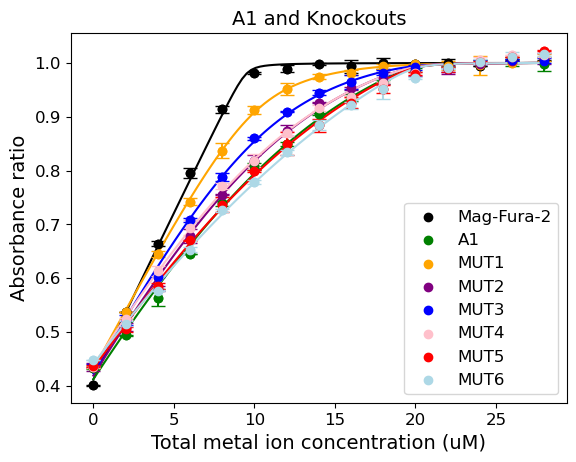

In [36]:
#Plot normalized data

#Dye (Mag-Fura-2)
plt.figure()   # open a fresh figure so this cell does not draw onto a previous one
plt.plot(data.iloc[:, 0], dye_fit_normalized, color='black')
plt.scatter(data.iloc[:, 2], dye_data_normalized, color='black', label='Mag-Fura-2')
plt.errorbar(data.iloc[:, 2], dye_data_normalized, yerr = dye_error_normalized, fmt='o', capsize=5, color='black')

#A1
plt.plot(data.iloc[:, 5], A1_fit_normalized, color='green')
plt.scatter(data.iloc[:, 7], A1_data_normalized, color='green', label='A1')
plt.errorbar(data.iloc[:, 7], A1_data_normalized, yerr = A1_error_normalized, fmt='o', capsize=5, color='green')

#MUT1
plt.plot(data.iloc[:, 10], MUT1_fit_normalized, color='orange')
plt.scatter(data.iloc[:, 12], MUT1_data_normalized, color='orange', label='MUT1')
plt.errorbar(data.iloc[:, 12], MUT1_data_normalized, yerr = MUT1_error_normalized, fmt='o', capsize=5, color='orange')

#MUT2
plt.plot(data.iloc[:, 15], MUT2_fit_normalized, color='purple')
plt.scatter(data.iloc[:, 17], MUT2_data_normalized, color='purple', label='MUT2')
plt.errorbar(data.iloc[:, 17], MUT2_data_normalized, yerr = MUT2_error_normalized, fmt='o', capsize=5, color='purple')

#MUT3
plt.plot(data.iloc[:, 20], MUT3_fit_normalized, color='blue')
plt.scatter(data.iloc[:, 22], MUT3_data_normalized, color='blue', label='MUT3')
plt.errorbar(data.iloc[:, 22], MUT3_data_normalized, yerr = MUT3_error_normalized, fmt='o', capsize=5, color='blue')

#MUT4
plt.plot(data.iloc[:, 25], MUT4_fit_normalized, color='pink')
plt.scatter(data.iloc[:, 27], MUT4_data_normalized, color='pink', label='MUT4')
plt.errorbar(data.iloc[:, 27], MUT4_data_normalized, yerr = MUT4_error_normalized, fmt='o', capsize=5, color='pink')

#MUT5
plt.plot(data.iloc[:, 30], MUT5_fit_normalized, color='red')
plt.scatter(data.iloc[:, 32], MUT5_data_normalized, color='red', label='MUT5')
plt.errorbar(data.iloc[:, 32], MUT5_data_normalized, yerr = MUT5_error_normalized, fmt='o', capsize=5, color='red')

#MUT6
plt.plot(data.iloc[:, 35], MUT6_fit_normalized, color='lightblue')
plt.scatter(data.iloc[:, 37], MUT6_data_normalized, color='lightblue', label='MUT6')
plt.errorbar(data.iloc[:, 37], MUT6_data_normalized, yerr = MUT6_error_normalized, fmt='o', capsize=5, color='lightblue')

plt.xlabel('Total metal ion concentration (uM)', fontsize=14)
plt.ylabel('Absorbance ratio', fontsize=14)
plt.title('A1 and Knockouts', fontsize=14)
plt.xticks(fontsize=12) 
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
save_figure(f'{wetlab_data_plots_dir}zinc_affinity_absorbance_ratio_plot', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()

# **IV. TOTAL CATALYTIC TURNOVER DATA** 

## IV.I. Total Turnover Experiment for ZETA_1

### IV.I.A. Progress Curves for the Total Turnover Experiment (Enzyme-Catalyzed, Background, & 4MU Product Standards)

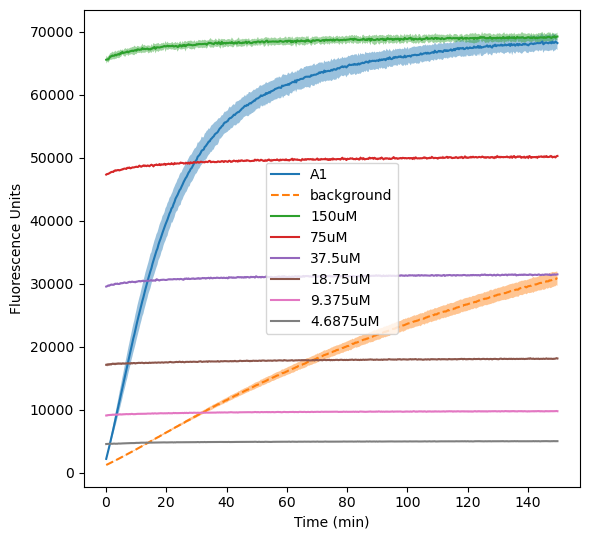

In [37]:
# excel file output from neo2
excel_file = f'{raw_wetlab_data_dir}241008_a1_turnover_100nM_enz_AND_150uM_4muPA_40x_ZINC_blank2ndROW_ladder150uMdown.xlsx'

# Specify row and column ranges
row_column_ranges = {
    'A': (5, 7),
    'B': (5, 7),
    'C': (5, 7),
    'D': (5, 7),
    'E': (5, 7),
    'F': (5, 7),
    'G': (5, 7),
    'H': (5, 7),
}

enzyme_row = "A"

# Specify replicates
replicate_dic = {
    5: [6, 7]
}

# Specify background
background_row = "B"

# Specify standard wells
standard_wells = [["150uM", ["C5", "C6", "C7"]], ["75uM", ["D5", "D6", "D7"]], ["37.5uM", ["E5", "E6", "E7"]], ["18.75uM", ["F5", "F6", "F7"]], ["9.375uM", ["G5", "G6", "G7"]], ["4.6875uM", ["H5", "H6", "H7"]]]

# Specify time ranges to show
max_time = 150 # minutes

# Create an empty list to store active wells
active_wells = []

# Iterate through rows/columns, append to active wells
for row, (start_col, end_col) in row_column_ranges.items():
    for col in range(start_col, end_col + 1):
        active_wells.append(f"{row}{col}")

# Load data
screening_data = parse_kinetics(excel_file, active_wells, start_row=48)

# Convernting time
screening_data["Time"] = screening_data["Time"]/60
screening_data = screening_data[screening_data["Time"] < max_time]

plt.figure(figsize=(6, 5.5))

for representive_col in replicate_dic:
    replicates = [representive_col]
    replicates.extend(replicate_dic[representive_col])

    
    replicates_well = [f"{enzyme_row}{col}" for col in replicates]
    avg_product_concentration = np.array(screening_data[replicates_well].mean(axis=1).tolist())
    std_product_concentration = np.array(screening_data[replicates_well].std(axis=1).tolist())
    plt.plot(screening_data["Time"].values, avg_product_concentration, label="A1")
    plt.fill_between(screening_data["Time"].values, 
                         avg_product_concentration - std_product_concentration,
                         avg_product_concentration + std_product_concentration,
                         alpha = 0.45)

    replicates_well = [f"{background_row}{col}" for col in replicates]
    avg_product_concentration = np.array(screening_data[replicates_well].mean(axis=1).tolist())
    std_product_concentration = np.array(screening_data[replicates_well].std(axis=1).tolist())
    plt.plot(screening_data["Time"].values, avg_product_concentration, linestyle='dashed', label="background")
    plt.fill_between(screening_data["Time"].values, 
                         avg_product_concentration - std_product_concentration,
                         avg_product_concentration + std_product_concentration,
                         alpha = 0.45)
    
    for product_label, replicates_well in standard_wells:
        avg_product_concentration = np.array(screening_data[replicates_well].mean(axis=1).tolist())
        std_product_concentration = np.array(screening_data[replicates_well].std(axis=1).tolist())
        plt.plot(screening_data["Time"].values, avg_product_concentration, label=product_label)
        plt.fill_between(screening_data["Time"].values, 
                             avg_product_concentration - std_product_concentration,
                             avg_product_concentration + std_product_concentration,
                             alpha = 0.45)
    
    plt.ylabel("Fluorescence Units")
    plt.xlabel("Time (min)")

plt.legend()
plt.tight_layout()
save_figure(f'{wetlab_data_plots_dir}241009_A1_turnover_experiment', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()

### IV.I.B. Product Fluorescence Standard Curve

Calibration R-squared: 0.9999993719322088


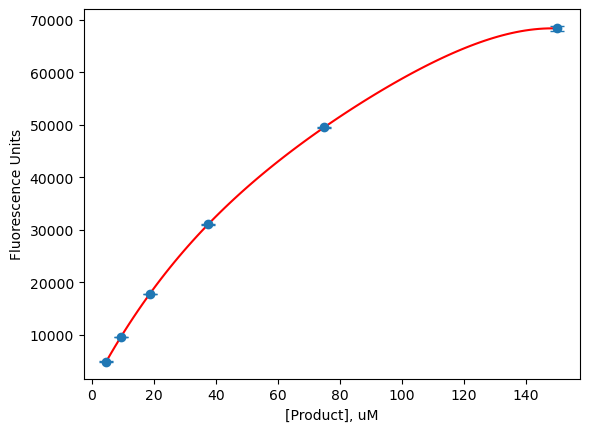

In [38]:
from scipy.stats import pearsonr

calibration_x = []
calibration_y = []
calibration_y_std = []

enzyme_concentration = 0.1 # uM

standard_wells = [["150uM", ["C5", "C6", "C7"]], ["75uM", ["D5", "D6", "D7"]], ["37.5uM", ["E5", "E6", "E7"]], ["18.75uM", ["F5", "F6", "F7"]], ["9.375uM", ["G5", "G6", "G7"]], ["4.6875uM", ["H5", "H6", "H7"]]]
for product_concentration, well_list in standard_wells:
    #calibration_y.append(float(product_concentration[:-2])/enzyme_concentration)
    calibration_x.append(float(product_concentration[:-2]))
    #calibration_y.append(float(product_concentration[:-2]))
    calibration_y.append(np.mean(np.array(screening_data[well_list].mean(axis=0).tolist())))
    calibration_y_std.append(np.std(np.array(screening_data[well_list].mean(axis=0).tolist())))
    #calibration_x.append(np.mean(np.array(screening_data[well_list].mean(axis=0).tolist())))
    
plt.figure()   # open a fresh figure so this cell does not draw onto a previous one
plt.errorbar(calibration_x, calibration_y, yerr=calibration_y_std, fmt="o", capsize=5)


#coefficients = np.polyfit(calibration_x, calibration_y, 1)
#print ("Coefficients:", coefficients)
#poly = np.poly1d(coefficients)
"""
x_fit = np.linspace(min(calibration_x), max(calibration_x), 100)
y_fit = poly(x_fit)
plt.plot(y_fit, x_fit, color='red', label='Fitted Line')
"""
coefficients = np.polyfit(calibration_x, calibration_y, 4)
poly = np.poly1d(coefficients)
# The displayed calibration maps concentration -> fluorescence. Conversion of
# reaction measurements needs the opposite direction (FU -> concentration).
# Fit that direction explicitly with the same fourth-order calibration model.
fluorescence_to_4mu = np.poly1d(np.polyfit(calibration_y, calibration_x, 4))
x_fit = np.linspace(min(calibration_x), max(calibration_x), 100)
y_fit = poly(x_fit)
plt.plot(x_fit, y_fit, color='red', label='Fitted Line')

calibration_residuals = np.asarray(calibration_y) - poly(calibration_x)
calibration_r_squared = 1 - np.sum(calibration_residuals**2) / np.sum(
    (np.asarray(calibration_y) - np.mean(calibration_y))**2)
print("Calibration R-squared:", calibration_r_squared)
plt.ylabel("Fluorescence Units")
#plt.ylabel("Turnover Number")
plt.xlabel("[Product], uM")
save_figure(f'{wetlab_data_plots_dir}241009_calibration_curve_for_turnover_number_experiment', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()

### IV.I.C. Turnover Number Plot

Convert fluorescence to 4MU concentration before dividing by the enzyme
concentration. The first plot retains enzyme and background traces separately;
the second subtracts the corresponding background replicate after conversion,
as in Fig. 3e and Supplementary Methods §4.3. The quartic calibration is specific
to this plate; values near its limits are estimates, not an extension of the
instrument's validated range.

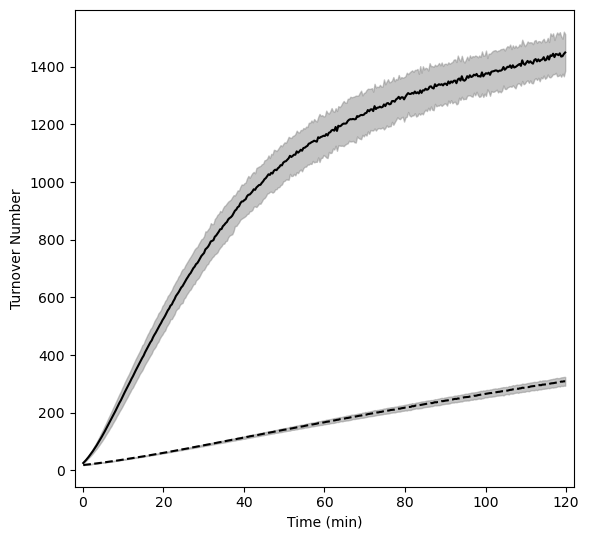

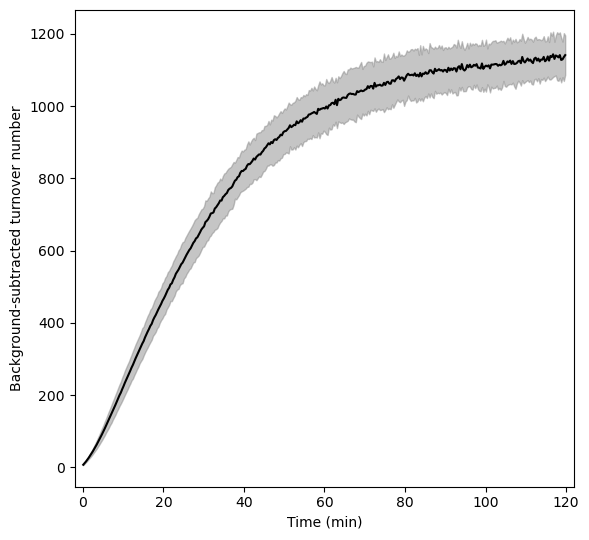

Net turnover at 119.8 min: 1141 ± 55 (mean ± SD, n=3)


In [39]:
enzyme_concentration = 0.1 # uM

converted_screening_data = pd.DataFrame()
converted_screening_data["Time"] = screening_data["Time"]
for well in active_wells:
    converted_screening_data[well] = fluorescence_to_4mu(screening_data[well].to_numpy(dtype=float)) / enzyme_concentration
converted_screening_data = converted_screening_data[converted_screening_data["Time"] < 120]
    
plt.figure(figsize=(6, 5.5))

for representive_col in replicate_dic:
    replicates = [representive_col]
    replicates.extend(replicate_dic[representive_col])

    
    replicates_well = [f"{enzyme_row}{col}" for col in replicates]
    bg_replicates_well = [f"{background_row}{col}" for col in replicates]
    
    avg_product_concentration = np.array(converted_screening_data[replicates_well].mean(axis=1).tolist())
    std_product_concentration = np.array(converted_screening_data[replicates_well].std(axis=1).tolist())
    plt.plot(converted_screening_data["Time"].values, avg_product_concentration, label="A1", color="black")
    plt.fill_between(converted_screening_data["Time"].values, 
                         avg_product_concentration - std_product_concentration,
                         avg_product_concentration + std_product_concentration,
                         alpha = 0.45, color="gray")

    avg_product_concentration = np.array(converted_screening_data[bg_replicates_well].mean(axis=1).tolist())
    std_product_concentration = np.array(converted_screening_data[bg_replicates_well].std(axis=1).tolist())
    plt.plot(converted_screening_data["Time"].values, avg_product_concentration, linestyle='dashed', label="background", color="black")
    plt.fill_between(converted_screening_data["Time"].values, 
                         avg_product_concentration - std_product_concentration,
                         avg_product_concentration + std_product_concentration,
                         alpha = 0.45, color="gray")
    
    #plt.ylabel("[Product]")
    plt.ylabel("Turnover Number")
    plt.xlabel("Time (min)")

plt.xlim(-2, 122)
#plt.ylim(-20, 1400)
plt.tight_layout()
save_figure(f'{wetlab_data_plots_dir}241009_A1_turnover_experiment_y_axis_turnover_not_zeroing', dpi=FIGURE_DPI, save_eps=SAVE_EPS)  # PNG always; EPS only if SAVE_EPS. Raise dpi here for one figure.
plt.show()

# Background-subtracted turnover number (Fig. 3e). Subtraction must follow the
# nonlinear FU -> concentration conversion; subtracting raw FU is not equivalent.
enzyme_wells = [f"{enzyme_row}{col}" for col in replicates]
background_wells = [f"{background_row}{col}" for col in replicates]
net_turnover = (converted_screening_data[enzyme_wells].to_numpy()
                - converted_screening_data[background_wells].to_numpy())
net_turnover_mean = net_turnover.mean(axis=1)
net_turnover_sd = net_turnover.std(axis=1, ddof=1)
plt.figure(figsize=(6, 5.5))
plt.plot(converted_screening_data["Time"], net_turnover_mean, color="black")
plt.fill_between(converted_screening_data["Time"],
                 net_turnover_mean - net_turnover_sd,
                 net_turnover_mean + net_turnover_sd, color="gray", alpha=0.45)
plt.xlabel("Time (min)")
plt.ylabel("Background-subtracted turnover number")
plt.xlim(-2, 122)
plt.tight_layout()
save_figure(f'{wetlab_data_plots_dir}241009_A1_turnover_background_subtracted',
            dpi=FIGURE_DPI, save_eps=SAVE_EPS)
plt.show()
print(f"Net turnover at {converted_screening_data['Time'].iloc[-1]:.1f} min: "
      f"{net_turnover_mean[-1]:.0f} ± {net_turnover_sd[-1]:.0f} (mean ± SD, n=3)")


# **V. BIOPHYSICAL CHARACTERIZATION DATA** 

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# CD spectroscopy functions (smooth_dataframe, plot_CD_spectrum_temperature_interval,
# plot_CD_spectrum_temperature_interval_A1, plot_CD_222nm_temperature_interval)
# are imported via the setup cell

## V.I. Circular Dichroism (CD) Spectra for Best Design from Each Unique Scaffold Hit



### V.I.A. A1 ([Enz]: 0.5mg/ml (27.5 uM), 25mM Tris, 25mM NaCl, Temp: 25C)

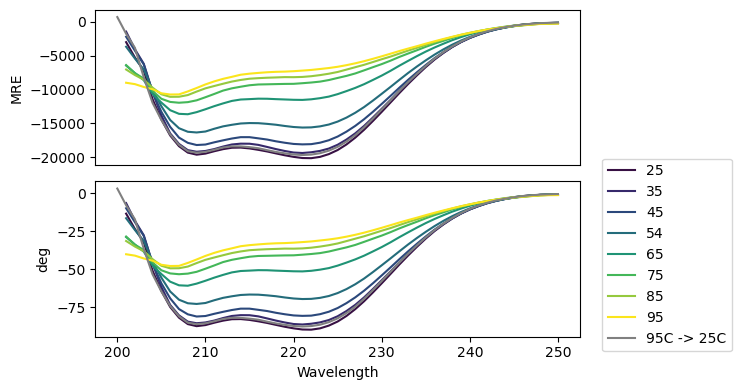

In [41]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "A1_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_Spectrum.csv"
file_name2 = "A1_25mMtris_25mMnacl_ph8_25C___recoveryAFTER95C-x-1.csv"

pathlength = 1 # Unit: mm
protein_concentration = 27.5 * 1e-6
protein_length = 162

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250326_CD_temp_interval_A1_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###
wavelength_min = 200
window_size = 5
colors = ["#371043", "#36296b", "#2b487b", "#246c7b", "#1f9375", "#44b759", "#95c93e", "#fbe51c"]

plot_CD_spectrum_temperature_interval_A1(os.path.join(CD_result_path, file_name), os.path.join(CD_result_path, file_name2), protein_concentration, protein_length, pathlength=pathlength, wavelength_min=wavelength_min, window_size=window_size, colors=colors, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

/home/woodbuse/publication/metallohydrolase/official_github/Metallohydrolase_Enzyme_Design/Scripts/experimental_data_processing_functions.py:711: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='center left', bbox_to_anchor=(1.0, 0.35))


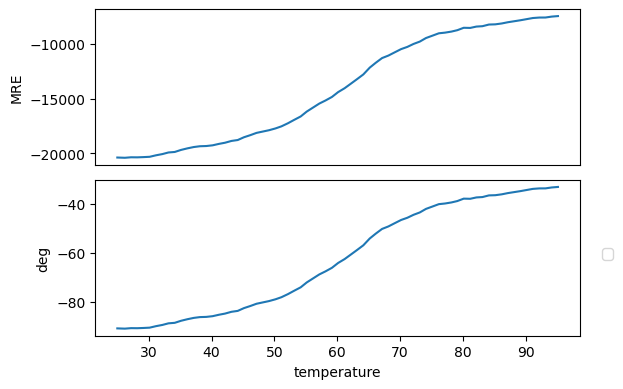

In [42]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "A1_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_222nmMeasurement.csv"

pathlength = 1 # Unit: mm
protein_concentration = 27.5 * 1e-6
protein_length = 162

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250326_CD_temp_interval_222nm_A1_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###
plot_CD_222nm_temperature_interval(os.path.join(CD_result_path, file_name), protein_concentration, protein_length, window_size=3, pathlength=pathlength, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### V.I.B. 250328 A8 ([Enz]: 19.3 uM, 25mM Tris, 25mM NaCl, Temp: 25C)

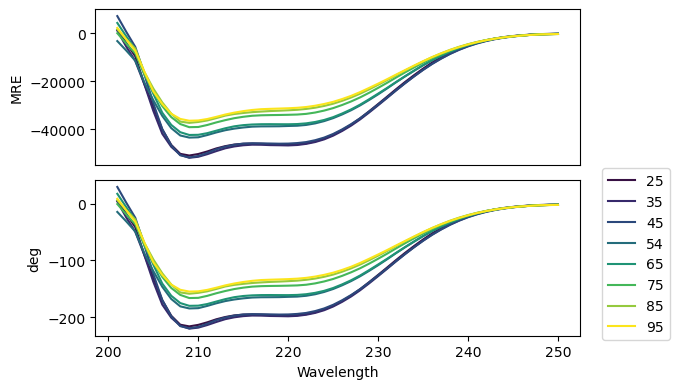

In [43]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "A8_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_Spectrum.csv"

pathlength = 1 # Unit: mm
protein_concentration = 19.3 * 1e-6
protein_length = 220

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250328_CD_temp_interval_A8_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###
wavelength_min = 200
window_size = 5
colors = ["#371043", "#36296b", "#2b487b", "#246c7b", "#1f9375", "#44b759", "#95c93e", "#fbe51c"]

plot_CD_spectrum_temperature_interval(os.path.join(CD_result_path, file_name), protein_concentration, protein_length, pathlength=pathlength, wavelength_min=wavelength_min, window_size=window_size, colors=colors, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### V.I.C. 250328 B9 ([Enz]: 22.4 uM, 25mM Tris, 25mM NaCl, Temp: 25C)

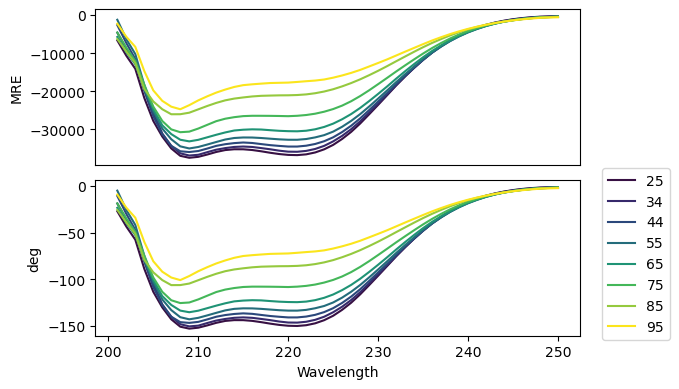

In [44]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "B9_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_Spectrum.csv"

pathlength = 1 # Unit: mm
protein_concentration = 22.4 * 1e-6
protein_length = 182

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250328_CD_temp_interval_B9_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###
wavelength_min = 200
window_size = 5
colors = ["#371043", "#36296b", "#2b487b", "#246c7b", "#1f9375", "#44b759", "#95c93e", "#fbe51c"]

plot_CD_spectrum_temperature_interval(os.path.join(CD_result_path, file_name), protein_concentration, protein_length, pathlength=pathlength, wavelength_min=wavelength_min, window_size=window_size, colors=colors, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### V.I.D. 250328 C4 ([Enz]: 25.7 uM, 25mM Tris, 25mM NaCl, Temp: 25C)

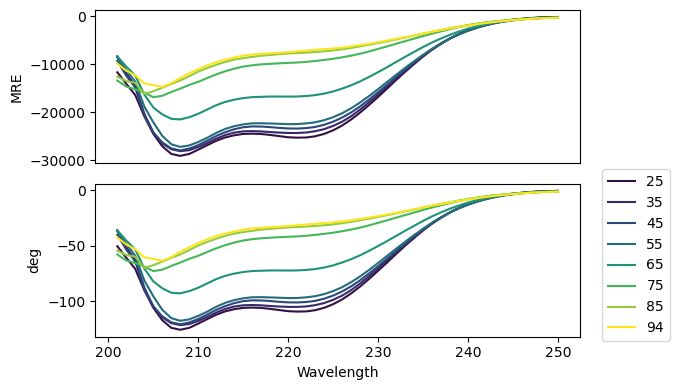

In [45]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "C4pa_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_Spectrum.csv"

pathlength = 1 # Unit: mm
protein_concentration = 25.7 * 1e-6
protein_length = 168

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250328_CD_temp_interval_C4_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###
wavelength_min = 200
window_size = 5
colors = ["#371043", "#36296b", "#2b487b", "#246c7b", "#1f9375", "#44b759", "#95c93e", "#fbe51c"]

plot_CD_spectrum_temperature_interval(os.path.join(CD_result_path, file_name), protein_concentration, protein_length, pathlength=pathlength, wavelength_min=wavelength_min, window_size=window_size, colors=colors, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### V.I.E. 250328 F7 ([Enz]: 28.1 uM, 25mM Tris, 25mM NaCl, Temp: 25C)

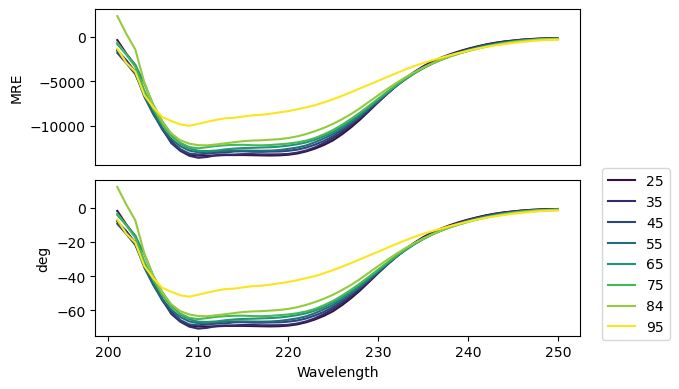

In [46]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "F7_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_Spectrum.csv"

pathlength = 1 # Unit: mm
protein_concentration = 28.1 * 1e-6
protein_length = 185

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250328_CD_temp_interval_F7_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###
wavelength_min = 200
window_size = 5
colors = ["#371043", "#36296b", "#2b487b", "#246c7b", "#1f9375", "#44b759", "#95c93e", "#fbe51c"]

plot_CD_spectrum_temperature_interval(os.path.join(CD_result_path, file_name), protein_concentration, protein_length, pathlength=pathlength, wavelength_min=wavelength_min, window_size=window_size, colors=colors, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### V.I.F. 250328 H10 ([Enz]: 33.1 uM, 25mM Tris, 25mM NaCl, Temp: 25C)

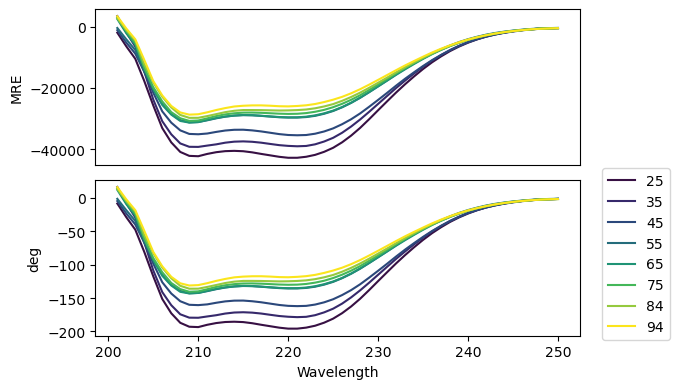

In [47]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "H10_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_Spectrum.csv"

pathlength = 1 # Unit: mm
protein_concentration = 33.1 * 1e-6
protein_length = 138

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250328_CD_temp_interval_H10_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###cc
wavelength_min = 200
window_size = 5
colors = ["#371043", "#36296b", "#2b487b", "#246c7b", "#1f9375", "#44b759", "#95c93e", "#fbe51c"]

plot_CD_spectrum_temperature_interval(os.path.join(CD_result_path, file_name), protein_concentration, protein_length, pathlength=pathlength, wavelength_min=wavelength_min, window_size=window_size, colors=colors, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### V.I.G. 250328 H6 ([Enz]: 39.4 uM, 25mM Tris, 25mM NaCl, Temp: 25C)

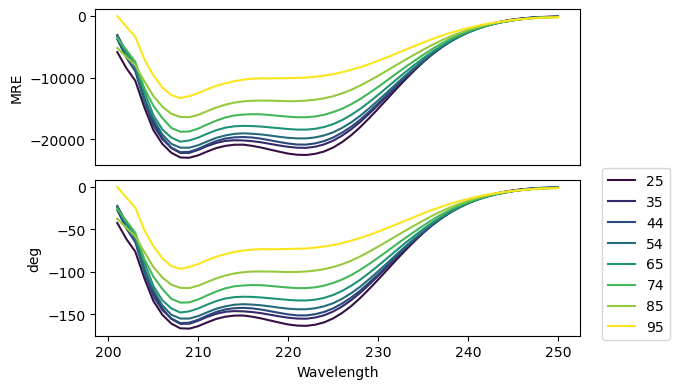

In [48]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "H6_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_Spectrum.csv"

pathlength = 1 # Unit: mm
protein_concentration = 39.4 * 1e-6
protein_length = 184

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250328_CD_temp_interval_H6_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###
wavelength_min = 200
window_size = 5
colors = ["#371043", "#36296b", "#2b487b", "#246c7b", "#1f9375", "#44b759", "#95c93e", "#fbe51c"]

plot_CD_spectrum_temperature_interval(os.path.join(CD_result_path, file_name), protein_concentration, protein_length, pathlength=pathlength, wavelength_min=wavelength_min, window_size=window_size, colors=colors, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)

### V.I.H. 250416 C5 ([Enz]: 16.5 uM, 25mM Tris, 25mM NaCl, Temp: 25C)

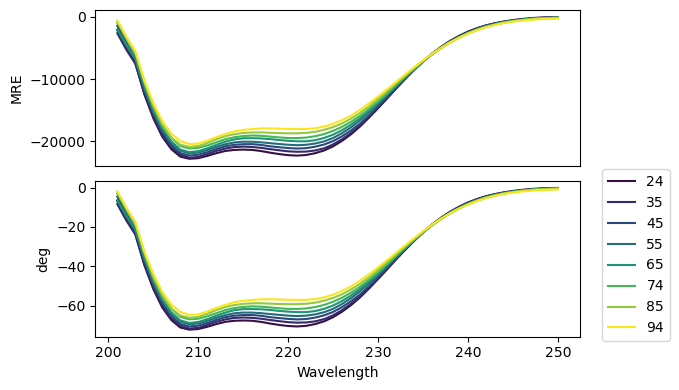

In [49]:
### Input ###
CD_result_path = raw_wetlab_data_dir
file_name = "C5_25mMtris_25mMnacl_ph8_noAddedZn__25C_to_95C_1nmBand_Spectrum.csv"

pathlength = 1 # Unit: mm
protein_concentration = 16.5 * 1e-6
protein_length = 192

### Output ###
save_eps_path = os.path.join(wetlab_data_plots_dir, "250416_CD_temp_interval_C5_25mMtris_25mMnacl_ph8_noAddedZn")

## Parameter ###
wavelength_min = 200
window_size = 5
colors = ["#371043", "#36296b", "#2b487b", "#246c7b", "#1f9375", "#44b759", "#95c93e", "#fbe51c"]

plot_CD_spectrum_temperature_interval(os.path.join(CD_result_path, file_name), protein_concentration, protein_length, pathlength=pathlength, wavelength_min=wavelength_min, window_size=window_size, colors=colors, save=save_eps_path, dpi=FIGURE_DPI, save_eps=SAVE_EPS)